# Importing packages

In [580]:
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
import scipy as sp
import os
import sys
import yaml
from pathlib import Path
from collections import OrderedDict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
from matplotlib import colormaps
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
from scipy.ndimage import gaussian_filter, binary_fill_holes, distance_transform_edt
from skimage import measure, morphology
from skimage.filters import threshold_otsu
from skimage.segmentation import find_boundaries
from shapely.geometry import Polygon
from shapely.geometry import Point
sys.path.append(os.path.abspath(".."))
rcParams['font.family'] = 'Arial'
from utils import extract_all_tumor_cores_otsu, extract_interaction
from matplotlib.colors import TwoSlopeNorm
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
import matplotlib as mpl
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["text.color"] = "black"
mpl.rcParams["axes.labelcolor"] = "black"
mpl.rcParams["xtick.color"] = "black"
mpl.rcParams["ytick.color"] = "black"

# Call the local folders with the data

In [6]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Set up directories
results_dir = Path(config['results_dir'])
metadata_dir = Path(config['metadata_dir'])

# Read the adata object

In [7]:
adata = ad.read(results_dir / 'adata.h5ad')

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/__init__.py:55: FutureWarning:

`anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning:

Transforming to str index.



# Define cell category column, cell order, and cell colors

In [8]:
##get the color scheme
conditions = [
    adata.obs['cell_type'] == 'CD4+_T_cells',
    adata.obs['cell_type'] == 'CD8+_T_cells',
    adata.obs['cell_type'] == "Treg_T_cells",
    adata.obs['cell_type'] == 'NK_cells',
    adata.obs['cell_type'] == "M1_macrophages",
    adata.obs['cell_type'] == "M2_macrophages",
    adata.obs['cell_type'] == "M1_M2_macrophages",
    adata.obs['cell_type'] == "B_cells",
    adata.obs['cell_type'] == 'Plasma_cells',
    adata.obs['cell_type'] == 'DCs',
    adata.obs['cell_type'] == 'Granulocytes',
    adata.obs['cell_type'] == 'Mast_cells',
    adata.obs['cell_type'] == 'MDSCs',
    adata.obs['cell_type'] == 'Lymphatic_endothelial_cells',
    adata.obs['cell_type'] == 'Endothelial_cells',
    adata.obs['cell_type'] == 'Actin+_cells',
    adata.obs['cell_type'] == 'Tumor_cells',
    adata.obs['cell_type'] == 'Epithelial_cells',
    adata.obs['cell_type'] == 'NFC'
]

# Define the corresponding labels
labels = [
    'CD4+ T cells',
    'CD8+ T cells',
    'Treg cells',
    'NK cells',
    'M1 macrophages',
    'M2 macrophages',
    'M1/M2 macrophages',
    'B cells',
    'PCs',
    'DCs',
    'Granulocytes',
    'Mast cells',
    'MDSCs',
    'Lymphatic endothelial cells',
    'Endothelial cells',
    'Actin+ cells',
    'Tumor cells',
    'Epithelial cells',
    'NFC'
]

#using np.select
adata.obs['cell_category'] = np.select(conditions, labels, default='Other')


cell_category_color = {
    "Actin+ cells": "#AAAAFF",
    "B cells": "#FFFF00",
    "DCs": "#00FF00",
    "Endothelial cells": "#55FFFF",
    "Granulocytes": "#FF00FF",
    "Lymphatic endothelial cells": "#0055FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "NFC": "#A9A9A9",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000",
    "Treg cells": "#AAFF7F",
    "Tumor cells": "#555555",
    "Epithelial cells": "#FFCC99",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}

myeloid_color = {
    "DCs": "#00FF00",
    "Granulocytes": "#FF00FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}

lymphoid_color = {
    "B cells": "#FFFF00",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "Treg cells": "#AAFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000",  
}

#all cell types order
all_ct_order = ["Treg cells", "CD8+ T cells", "CD4+ T cells", "NK cells",  "PCs", "B cells", "DCs", 
                "Mast cells", "Granulocytes", "M1/M2 macrophages", "M1 macrophages", "M2 macrophages",  
                "MDSCs", "Lymphatic endothelial cells", "Endothelial cells", "Epithelial cells", "NFC", "Actin+ cells", "Tumor cells"]
lymphoid_order = ["Treg cells", "CD8+ T cells", "CD4+ T cells", "NK cells",  "PCs", "B cells"]
myeloid_order = ["DCs", "Mast cells", "Granulocytes", "M1/M2 macrophages", "M1 macrophages", "M2 macrophages",  "MDSCs"]

In [ ]:
#calculate cell type proportiosn per site
counts_patient = adata.obs.groupby(['patient_ID', 'cell_category']).size().unstack(fill_value=0)
#turn them to percentages
counts_patient_percentage = counts_patient.div(counts_patient.sum(axis=1), axis=0) * 100
#sort order
counts_patient_percentage = counts_patient_percentage[all_ct_order]
#select only lymphoid cells
counts_lymphoid = counts_patient_percentage[lymphoid_color.keys()]
counts_lymphoid = counts_lymphoid[lymphoid_order]
#select only myeloid cells
counts_myeloid = counts_patient_percentage[myeloid_color.keys()]
counts_myeloid = counts_myeloid[myeloid_order]

In [ ]:
# Ensure consistent font & style
plt.rcParams['font.family'] = 'Arial'

# Create figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=True)

# --- All cells ---
cell_category_perc.plot(
    kind="barh", 
    stacked=True, 
    color=cell_category_color, 
    ax=axes[0], 
    edgecolor='black', 
    linewidth=0.2
)
axes[0].set_title("All cell types", fontsize=18)
axes[0].set_xlabel("Cells [%]")
axes[0].set_ylabel("Patient")
axes[0].legend().set_visible(False)
axes[0].grid(False)

# --- Lymphoid ---
counts_lymphoid.plot(
    kind="barh", 
    stacked=True, 
    color=lymphoid_color, 
    ax=axes[1], 
    edgecolor='black', 
    linewidth=0.2
)
axes[1].set_title("Lymphoid cells", fontsize=18)
axes[1].set_xlabel("Cells [%]")
axes[1].set_ylabel("")  # remove duplicate y-axis label
axes[1].legend().set_visible(False)
axes[1].grid(False)

# --- Myeloid ---
counts_myeloid.plot(
    kind="barh", 
    stacked=True, 
    color=myeloid_color, 
    ax=axes[2], 
    edgecolor='black', 
    linewidth=0.2
)
axes[2].set_title("Myeloid cells", fontsize=18)
axes[2].set_xlabel("Cells [%]")
axes[2].set_ylabel("")  # remove duplicate y-axis label
axes[2].legend().set_visible(False)
axes[2].grid(False)

# Formatting ticks
for ax in axes:
    ax.tick_params(axis='y', labelsize=8)
    for tick in ax.get_yticklabels():
        tick.set_ha('right')
        tick.set_fontsize(20)
#make y-axis title bigger
axes[0].yaxis.label.set_size(20)
#x-axis title bigger
fig.axes[0].xaxis.label.set_size(20)
fig.axes[1].xaxis.label.set_size(20)
fig.axes[2].xaxis.label.set_size(20)
plt.tight_layout()
plt.savefig(results_dir / "poster_combined_barplot.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import matplotlib.patches as mpatches

# Get handles and labels
handles, labels = axes[0].get_legend_handles_labels()

# Extract colors from each BarContainer
colors = [h.patches[0].get_facecolor() for h in handles]

# Sort labels & colors together alphabetically
labels, colors = zip(*sorted(zip(labels, colors), key=lambda x: x[0]))

# Make circular legend markers
circle_handles = [
    mpatches.Circle((0, 0), radius=5, facecolor=c, edgecolor="black")
    for c in colors
]

# Create a new figure just for the legend
fig_legend = plt.figure(figsize=(10, 3))
fig_legend.legend(
    circle_handles,
    labels,
    loc="center",
    ncol=7,          # adjust columns if needed
    frameon=False,
    fontsize=12,
    handlelength=1,
    handletextpad=0.5
)

plt.savefig(results_dir / "poster_combined_barplot_legend.svg", format='svg', dpi=300, bbox_inches='tight')
plt.show()


# Infiltration Function

# Run Tumor core detection function

In [ ]:
adata.obs['distance_to_tumor'] = np.nan
adata.obs['n_cores'] = np.nan
adata.obs['tumor_area'] = np.nan
for exp in adata.obs['patient_exp'].unique():
    print(f"Processing experiment: {exp}")
    # Subset adata for the current experiment
    adata_exp = adata[adata.obs['patient_exp'] == exp]
    polygons, distances, n_cores, tumor_area, on_contour_flags = extract_all_tumor_cores_otsu(adata_exp, plot=True, save=True, sigma=1, results_dir=results_dir)
    adata.obs.loc[adata_exp.obs.index, 'distance_to_tumor'] = distances
    adata.obs.loc[adata_exp.obs.index, 'n_cores'] = n_cores
    adata.obs.loc[adata_exp.obs.index, 'tumor_area'] = tumor_area
    adata.obs.loc[adata_exp.obs.index, 'tumor_edge'] = on_contour_flags

conditions = [
    (adata.obs['distance_to_tumor'] == 0) & (adata.obs['tumor_edge'] == False),
    ((adata.obs['distance_to_tumor'] == 0) & (adata.obs['tumor_edge'] == True)) |
    ((adata.obs['distance_to_tumor'] > 0) & (adata.obs['distance_to_tumor'] <= 400)),
    (adata.obs['distance_to_tumor'] > 400)
]

choices = ['Core (0μm)', 'Edge (0-100μm)', 'Distal (100+μm)']

adata.obs['tumor_proximity'] = np.select(conditions, choices, default='Distal')

adata.obs['tumor_proximity'] = pd.Categorical(adata.obs['tumor_proximity'], categories=['Core (0μm)', 'Edge (0-100μm)', 'Distal (100+μm)'], ordered=True)

In [ ]:
for patient_exp in adata.obs['patient_exp'].unique():
    adata_select = adata[adata.obs['patient_exp'] == patient_exp]
    coords = adata_select.obsm["spatial"]    # Nx2 array (x, y)
    x, y = coords[:, 0], coords[:, 1]
    categories = adata_select.obs["cell_category"]
    unique_cats = categories.unique()
    
    # --- Map categories to palette ---
    # `cell_category_color` should be a dict like {"cat1": "#hex", ...}
    colors = categories.map(cell_category_color)
    
    # --- Plot ---
    plt.figure(figsize=(10, 8))
    plt.scatter(
        x, y,
        c=colors,
        s=15,           # equivalent to spot_size
        alpha=0.8,
        linewidths=0,
    )
    
    plt.gca().invert_yaxis()
    
    
    # --- Remove frame/axes if desired ---
    plt.axis("off")
    
    #plt title
    plt.title(f'{patient_exp}', fontsize=16)
    
    # --- Legend ---
    for cat in unique_cats:
        plt.scatter([], [], c=cell_category_color[cat], label=cat, s=60, alpha=0.8)
    plt.legend(frameon=False, markerscale=1.5, bbox_to_anchor=(1, 1),   # move legend outside plot
        loc='upper left')
    
    plt.savefig(
    f"/Users/jawadalaaedeen/Desktop/PhD/NMC/results/poster_{patient_exp}_spatial_plot.svg",
    dpi=300,
    bbox_inches="tight" 
    )
    
    plt.show()


In [ ]:
coords = adata_select.obsm["spatial"]
x, y = coords[:, 0], coords[:, 1]


categories = adata_select.obs["tumor_proximity"]
unique_cats = categories.unique()

#color map
color_dict = {
    "Core (0μm)": "#D73027",      # magenta
    "Edge (0-100μm)": "#1A9850",   # blue
    "Distal (100+μm)": "#4575B4"   # yellow
}


plt.figure(figsize=(10, 10))

for cat in unique_cats:
    mask = categories == cat
    plt.scatter(
        x[mask], y[mask],
        s=15,
        alpha=0.8,
        linewidths=0,
        color=color_dict[cat],
        label=cat
    )

plt.gca().invert_yaxis()
plt.axis("off")
plt.title("NMC_7_ROI13", fontsize=16)

handles = [
    Line2D([0], [0], marker='o', color='w', label=cat,
           markerfacecolor=color_dict[cat], markersize=8)
    for cat in color_dict.keys()
]

plt.legend(handles=handles, frameon=False, markerscale=1.5,
           bbox_to_anchor=(1, 1), loc='upper left')


plt.savefig(
    "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/poster_NMC7_ROI13_spatial_plot_core.svg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Calculate Infiltration of only immune cells

In [79]:
excluded_cell_types = ["Endothelial cells", "Lymphatic endothelial cells", "NFC", "Epithelial cells", "Actin+ cells", "Tumor cells"]

# My method of infiltration

In [ ]:
infiltration = adata.obs.groupby(['patient_exp', 'cell_category']).agg(
    infiltration=('distance_to_tumor', lambda x: (x == 0).sum()),
    total_cells=('cell_category', 'count')
).reset_index()
infiltration = infiltration[~infiltration['cell_category'].isin(excluded_cell_types)]
#total infiltrated cells per patient
infiltration["total_cells"] = infiltration.groupby('patient_exp')['infiltration'].transform('sum')
infiltration['percentage'] = (infiltration['infiltration'] / infiltration['total_cells']) * 100
infiltration.to_csv(results_dir/'NMC_infiltration_percentage.csv')

#  Plot Infiltration

In [ ]:
pivot_df = infiltration.pivot_table(
    index="patient_exp",
    columns="cell_category",
    values="percentage",
    aggfunc="sum"
)

# --- Define your custom order ---
myeloid_lymphoid_category_order = [
    "MDSCs",
    "M2 macrophages",
    "M1 macrophages",
    "M1/M2 macrophages",
    "Granulocytes",
    "Mast cells",
    "DCs",
    "B cells",
    "PCs",
    "NK cells",
    "CD4+ T cells",
    "CD8+ T cells",
    "Treg cells",

]  

# --- Define custom colors ---
myeloid_lymphoid_category_color = {
    "B cells": "#FFFF00",
    "DCs": "#00FF00",
    "Granulocytes": "#FF00FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000FF",
    "Treg cells": "#AAFF7F",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}

# Reindex columns to your preferred order (ignore missing safely)
pivot_df = pivot_df.reindex(columns=[c for c in myeloid_lymphoid_category_order if c in pivot_df.columns])

colors = [myeloid_lymphoid_category_color[c] for c in pivot_df.columns]

# --- Plot (horizontal stacked barplot) ---
ax = pivot_df.plot(
    kind="barh",
    stacked=True,
    figsize=(10,10),   # make taller since now samples are on y-axis
    color=colors,
    edgecolor='black', 
    linewidth=0.2
)

plt.xlabel("Infiltrating Cells [%]", fontsize=20)
plt.ylabel("Sample", fontsize=20)
plt.title("Proportions of infiltrating immune cells", fontsize=20)

# Custom legend in same order as stack
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc="upper left", title="Cell type")

plt.savefig(results_dir / "poster_infiltration_horizontal.svg", format='svg', bbox_inches='tight')

plt.tight_layout()
plt.show()



/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_56481/1369739136.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_56481/1369739136.py:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_56481/1369739136.py:12: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



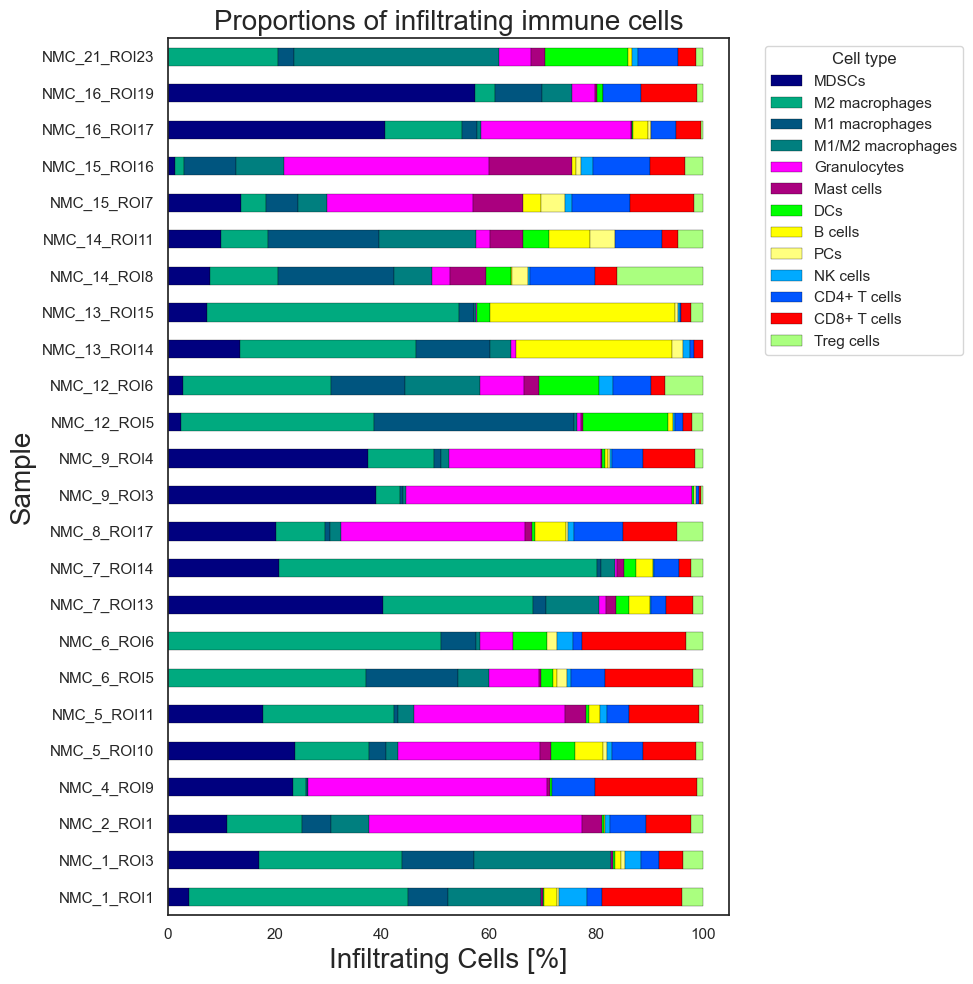

In [181]:
excluded_cell_types = ["Endothelial cells", "Lymphatic endothelial cells", "NFC", "Epithelial cells", "Actin+ cells", "Tumor cells"]

infiltration = adata.obs.groupby(['patient_exp', 'cell_category']).agg(
    infiltration=('distance_to_tumor', lambda x: (x == 0).sum()),
    total_cells=('cell_category', 'count')
).reset_index()
infiltration = infiltration[~infiltration['cell_category'].isin(excluded_cell_types)]
#total infiltrated cells per patient
infiltration["total_cells"] = infiltration.groupby('patient_exp')['infiltration'].transform('sum')
infiltration['percentage'] = (infiltration['infiltration'] / infiltration['total_cells']) * 100

pivot_df = infiltration.pivot_table(
    index="patient_exp",
    columns="cell_category",
    values="percentage",
    aggfunc="sum"
)

# --- Define your custom order ---
myeloid_lymphoid_category_order = [
    "MDSCs",
    "M2 macrophages",
    "M1 macrophages",
    "M1/M2 macrophages",
    "Granulocytes",
    "Mast cells",
    "DCs",
    "B cells",
    "PCs",
    "NK cells",
    "CD4+ T cells",
    "CD8+ T cells",
    "Treg cells",

]  

# --- Define custom colors ---
myeloid_lymphoid_category_color = {
    "B cells": "#FFFF00",
    "DCs": "#00FF00",
    "Granulocytes": "#FF00FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000FF",
    "Treg cells": "#AAFF7F",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}

# Reindex columns to your preferred order (ignore missing safely)
pivot_df = pivot_df.reindex(columns=[c for c in myeloid_lymphoid_category_order if c in pivot_df.columns])

colors = [myeloid_lymphoid_category_color[c] for c in pivot_df.columns]

# --- Plot (horizontal stacked barplot) ---
ax = pivot_df.plot(
    kind="barh",
    stacked=True,
    figsize=(10,10),   # make taller since now samples are on y-axis
    color=colors,
    edgecolor='black', 
    linewidth=0.2
)

plt.xlabel("Infiltrating Cells [%]", fontsize=20)
plt.ylabel("Sample", fontsize=20)
plt.title("Proportions of infiltrating immune cells", fontsize=20)

# Custom legend in same order as stack
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc="upper left", title="Cell type")


plt.tight_layout()
plt.show()


In [182]:
# get the metadata of survival
df = adata.obs[["patient_exp", "patient_ID", "survival_time_months"]].copy()

# ensure patient_exp is categorical
df["patient_exp"] = df["patient_exp"].astype("category")

# sort according to the category order of patient_exp
df = df.sort_values("patient_exp")

# keep only one row per patient_exp
df_unique = df.drop_duplicates(subset="patient_exp", keep="first")

pivot_df["survival_time_months"] = df_unique["survival_time_months"].values

pivot_df["patient_ID"] = df_unique["patient_ID"].values


In [183]:
granulocyte_infiltration = pivot_df[["patient_ID", "survival_time_months", "Granulocytes"]].copy()
#average them per patient
granulocyte_infiltration = granulocyte_infiltration.groupby("patient_ID").median().reset_index()
granulocyte_infiltration
#anything above 30% is high infiltration
granulocyte_infiltration['infiltration_group'] = np.where(granulocyte_infiltration['Granulocytes'] > 30, 'High', 'Low')
granulocyte_infiltration["event"] = 1
#remove patient 1 because outliers
granulocyte_infiltration = granulocyte_infiltration[granulocyte_infiltration["patient_ID"] != "NMC_1"]

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_56481/2161652080.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



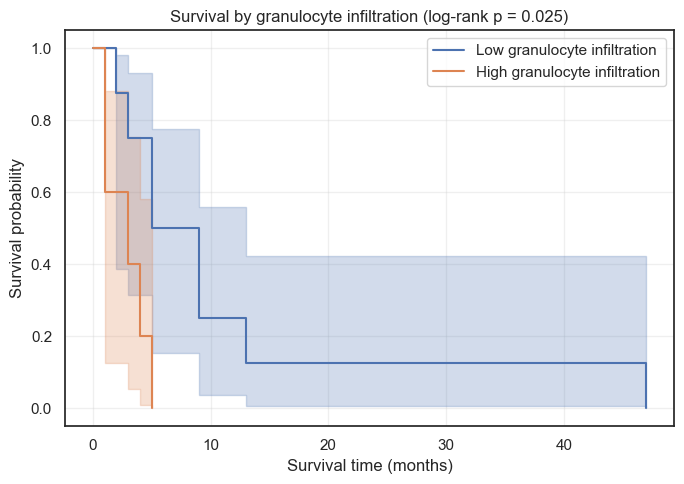

Log-rank test p-value: 0.02545402684301771


In [ ]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

# Make sure event is int/bool: 1=dead, 0=censored
# df["event"] = df["event"].astype(int)

# Split groups
low = granulocyte_infiltration[granulocyte_infiltration["infiltration_group"] == "Low"]
high = granulocyte_infiltration[granulocyte_infiltration["infiltration_group"] == "High"]

kmf_low = KaplanMeierFitter()
kmf_high = KaplanMeierFitter()

plt.figure(figsize=(7, 5))

# --- LOW group ---
kmf_low.fit(
    durations=low["survival_time_months"],
    event_observed=low["event"],
    label="Low granulocyte infiltration"
)
ax = kmf_low.plot(ci_show=True, show_censors=True)

# --- HIGH group ---
kmf_high.fit(
    durations=high["survival_time_months"],
    event_observed=high["event"],
    label="High granulocyte infiltration"
)
kmf_high.plot(ax=ax, ci_show=True, show_censors=True)

# --- Log-rank test ---
results = logrank_test(
    low["survival_time_months"],
    high["survival_time_months"],
    event_observed_A=low["event"],
    event_observed_B=high["event"]
)
p_value = results.p_value

# --- Cosmetics ---
plt.title(f"Survival by granulocyte infiltration (log-rank p = {p_value:.3f})")
plt.xlabel("Survival time (months)")
plt.ylabel("Survival probability")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()
print("Log-rank test p-value:", p_value)


In [186]:
macrophages_infiltration = pivot_df[["patient_ID", "survival_time_months", "M2 macrophages"]].copy()
#average them per patient
macrophages_infiltration = macrophages_infiltration.groupby("patient_ID").median().reset_index()
#anything above 30% is high infiltration
macrophages_infiltration['infiltration_group'] = np.where(macrophages_infiltration['M2 macrophages'] > 30, 'High', 'Low')
macrophages_infiltration["event"] = 1
#remove patient 1 because outliers
macrophages_infiltration = macrophages_infiltration[macrophages_infiltration["patient_ID"] != "NMC_1"]
macrophages_infiltration

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_56481/3235819371.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



cell_category,patient_ID,survival_time_months,M2 macrophages,infiltration_group,event
1,NMC_2,1.0,14.024390,Low,1
2,NMC_4,3.0,2.409147,Low,1
3,NMC_5,9.0,19.246605,Low,1
4,NMC_6,5.0,44.051323,High,1
5,NMC_7,9.0,43.663619,High,1
6,NMC_8,4.0,9.060956,Low,1
7,NMC_9,1.0,8.402476,Low,1
8,NMC_12,47.0,32.004831,High,1
9,NMC_13,5.0,39.997753,High,1
10,NMC_14,2.0,10.791659,Low,1


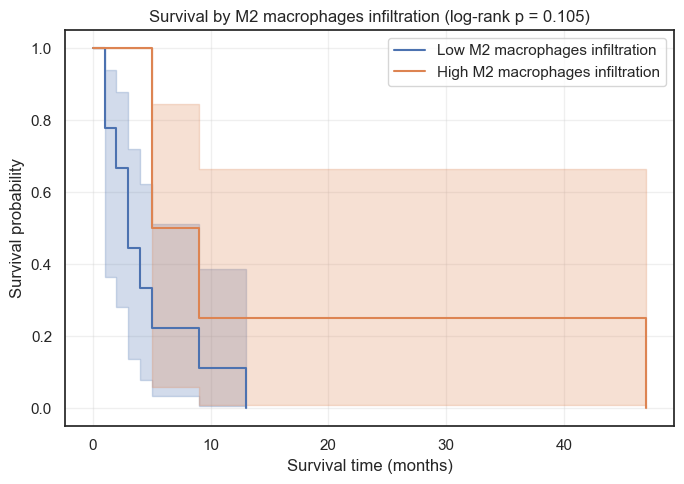

Log-rank test p-value: 0.10545053777393118


In [187]:
low = macrophages_infiltration[macrophages_infiltration["infiltration_group"] == "Low"]
high = macrophages_infiltration[macrophages_infiltration["infiltration_group"] == "High"]

kmf_low = KaplanMeierFitter()
kmf_high = KaplanMeierFitter()

plt.figure(figsize=(7, 5))

# --- LOW group ---
kmf_low.fit(
    durations=low["survival_time_months"],
    event_observed=low["event"],
    label="Low M2 macrophages infiltration"
)
ax = kmf_low.plot(ci_show=True, show_censors=True)

# --- HIGH group ---
kmf_high.fit(
    durations=high["survival_time_months"],
    event_observed=high["event"],
    label="High M2 macrophages infiltration"
)
kmf_high.plot(ax=ax, ci_show=True, show_censors=True)

# --- Log-rank test ---
results = logrank_test(
    low["survival_time_months"],
    high["survival_time_months"],
    event_observed_A=low["event"],
    event_observed_B=high["event"]
)
p_value = results.p_value

# --- Cosmetics ---
plt.title(f"Survival by M2 macrophages infiltration (log-rank p = {p_value:.3f})")
plt.xlabel("Survival time (months)")
plt.ylabel("Survival probability")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

print("Log-rank test p-value:", p_value)


## Spatial Interaction

In [166]:
sm.tl.spatial_interaction(adata,
                         x_coordinate='Cell Center X',
                         y_coordinate='Cell Center Y',
                         phenotype="cell_category",
                         method='delaunay',
                         permutation=300,
                         cond_counts_threshold= 3,
                         imageid='patient_exp',
                         subset=None,
                         pval_method='zscore',
                         normalization='conditional',
                         verbose=True,
                         label='scimap_delaunay_conditional_zscore')

Processing Image: ['NMC_14_ROI11']
Categories (1, object): ['NMC_14_ROI11']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_15_ROI16']
Categories (1, object): ['NMC_15_ROI16']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_15_ROI7']
Categories (1, object): ['NMC_15_ROI7']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_1_ROI3']
Categories (1, object): ['NMC_1_ROI3']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_16

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['NMC_8_ROI17']
Categories (1, object): ['NMC_8_ROI17']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['NMC_5_ROI11']
Categories (1, object): ['NMC_5_ROI11']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_6_ROI5']
Categories (1, object): ['NMC_6_ROI5']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


...

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['NMC_4_ROI9']
Categories (1, object): ['NMC_4_ROI9']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_13_ROI14']
Categories (1, object): ['NMC_13_ROI14']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_7_ROI14']
Categories (1, object): ['NMC_7_ROI14']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['NMC_7_ROI13']
Categories (1, object): ['NMC_7_ROI13']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_6_ROI6']
Categories (1, object): ['NMC_6_ROI6']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_12_ROI6']
Categories (1, object): ['NMC_12_ROI6']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results


AnnData object with n_obs × n_vars = 587448 × 144
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', 

# Extract Spatial Interactions Function

In [167]:
excluded_cell_types = ["Endothelial cells", "Lymphatic endothelial cells", "NFC", "Epithelial cells", "Tumor cells", "Actin+ cells"]

# Immune - Tumor Interaction

In [ ]:
interaction = extract_interaction(adata, 
                                  selected_cell_type="Tumor cells", 
                                  excluded_cell_types=excluded_cell_types, 
                                  direction="to", 
                                  cells_threshold=15, 
                                  save_data=True,
                                  results_dir=results_dir)
interaction

# Immune - Tumor Interaction

# Tumor - Immune Interaction

In [ ]:
interaction = extract_interaction(adata,
                                    selected_cell_type="Tumor cells",
                                    excluded_cell_types=excluded_cell_types, 
                                    direction="from", 
                                    cells_threshold=15, 
                                    save_data=True,
                                    results_dir=results_dir)
interaction

# MDSCs - Other Immune

In [ ]:
interaction = extract_interaction(adata,
                                    selected_cell_type="MDSCs", 
                                    excluded_cell_types=excluded_cell_types + ["MDSCs"], 
                                    direction="from", 
                                    cells_threshold=15, 
                                    save_data=True,
                                    results_dir=results_dir)
interaction

In [ ]:
interaction = extract_interaction(adata,
                                    selected_cell_type="CD8+_T_cells", 
                                    excluded_cell_types=excluded_cell_types + ["CD8+_T_cells", "CD4+_T_cells"], 
                                    direction="from", 
                                    cells_threshold=15, 
                                    save_data=True)

interaction = extract_interaction(adata,
                                    selected_cell_type="CD8+_T_cells", 
                                    excluded_cell_types=excluded_cell_types + ["CD8+_T_cells", "CD4+_T_cells"], 
                                    direction="to", 
                                    cells_threshold=15, 
                                    save_data=True)

interaction

# Chiara method of infiltration

In [ ]:
#Calculate infiltration to the tumor with COZI
infiltration = adata.uns['scimap_delaunay_conditional_zscore']
infiltration.index = infiltration["phenotype"] + "-" + infiltration["neighbour_phenotype"]
infiltration= infiltration.drop(columns=["phenotype", "neighbour_phenotype"])
infiltration = infiltration.filter(like='cond_cells_percentage', axis=1)
infiltration.columns = infiltration.columns.str.replace('cond_cells_percentage_', '')  # remove zscore_ from column names
ordered_columns = adata.obs.sort_values(by = "patient_ID").loc[:,["exp_name", "patient_ID", "patient_exp"]].drop_duplicates().reset_index(drop=True)
infiltration = infiltration[ordered_columns["patient_exp"]]
infiltration.columns = ordered_columns["patient_exp"].values
#only keep index that has Tumor-cells
infiltration = infiltration[infiltration.index.str.contains("-Tumor_cells")]
#make data in long format
infiltration_long = infiltration.reset_index().melt(id_vars='index', var_name='patient_exp', value_name='cond_cells_percentage')
infiltration_long.rename(columns={'index': 'cell_type'}, inplace=True)
#make second column the first column
infiltration_long = infiltration_long[['patient_exp', 'cell_type', 'cond_cells_percentage']]
infiltration_long['cell_type'] = infiltration_long['cell_type'].str.replace('-Tumor_cells', '', regex=False)
total_cells = adata.obs.groupby(["patient_exp", "cell_type"]).size().reset_index(name='total_cells')
infiltration_long = infiltration_long.merge(total_cells, on=['patient_exp', 'cell_type'], how='left')
infiltration_long.loc[infiltration_long["total_cells"] < 15, "cond_cells_percentage"] = np.nan
infiltration_long = infiltration_long.drop(columns=["total_cells"])
# infiltration_long["total_cells"] = adata.obs.groupby(["patient_exp", "cell_type"])["cell_type"].count().values
# #make distance_to_tumor NA for any row with less than 20 total_cells
# infiltration_long.loc[infiltration_long["total_cells"] <= 15, "cell_type"] = np.nan
# infiltration_long = infiltration_long[~infiltration_long["cell_type"].isin(["Tumor_cells"])]
#take out stromal cells and tumor cells
infiltration_long = infiltration_long[~infiltration_long["cell_type"].isin(excluded_cell_types)]
#save infiltration_long
infiltration_long.to_csv(results_dir / "NMC_cozi_infiltration.csv", index=False)

# Spatial distance

In [ ]:
adata = sm.tl.spatial_distance (adata, phenotype='cell_category', x_coordinate="Cell Center X", y_coordinate="Cell Center Y", imageid='patient_exp')

In [95]:
adata = sm.tl.spatial_distance (adata, phenotype='cell_category', x_coordinate="Cell Center X", y_coordinate="Cell Center Y", imageid='patient_exp')

# --- Data prep ---
distances = adata.uns['spatial_distance']
distances["cell_category"] = adata.obs['cell_category'].values
distances = distances.loc[:, ["cell_category", "Tumor cells"]]
distances["Tumor cells"] = distances["Tumor cells"] * 0.17 # convert pixels to microns
# Order by median distance
order = (
    distances.groupby("cell_category")["Tumor cells"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# Counts for each cell type
counts = distances["cell_category"].value_counts().reindex(order)

In [ ]:
# --- Plot ---
fig, ax_violin = plt.subplots(figsize=(16, 16))

# Distance violinplot
sns.violinplot(
    data=distances,
    x="Tumor cells",
    y="cell_category",
    order=order,
    palette=cell_category_color,   # <--- your custom colors here
    scale="width",
    ax=ax_violin,
    log_scale=True
)
#increase size of y-axis labels 
ax_violin.tick_params(axis='y', labelsize=20)
# Axis labels
ax_violin.set_xlabel(
    "Distance to the closest tumor cell (log10µm)",
    fontsize=20
)
ax_violin.set_ylabel(
    "All Cell types",
    fontsize=20
)

# Add counts on the right side
for i, cell_category in enumerate(order):
    count_val = counts[cell_category]
    ax_violin.text(
        x=ax_violin.get_xlim()[1] * 1.09,
        y=i,
        s=f"{count_val:,}",
        va="center",
        ha="left",
        fontfamily="Arial",
        fontsize = 18
    )

# Add label for counts (once)
ax_violin.text(
    x=ax_violin.get_xlim()[1] * 1.03,
    y=len(order) + 0.5,
    s="Cell count",
    va="bottom", ha="left",
    fontfamily="Arial", 
    fontsize = 18
)

# Remove right/top spines
sns.despine(ax=ax_violin, right=True, top=True)

#save svg figure
plt.savefig(results_dir / "poster_distance_to_tumor_cells.svg", format='svg', bbox_inches='tight', dpi = 300)

plt.tight_layout()
plt.show()



In [ ]:
#average cell type per patient per cell type
distances["patient_exp"] = adata.obs['patient_exp'].values
distances_average = distances.groupby(['patient_exp', 'cell_category'])['Tumor cells'].median().reset_index()
#zscore per patient
distances_average['zscore'] = distances_average.groupby('patient_exp')['Tumor cells'].transform(lambda x: (x - x.mean()) / x.std())
distances_average

In [ ]:
#resolution is 0.17 microns per pixel
distances_um = distances.copy()
distances_um["Tumor cells"] = distances_um["Tumor cells"] * 0.17

# Pick the cell types you want to compare
cell_types = adata.obs.cell_category.unique()

plt.figure(figsize=(10,6))  # bigger figure

highlight = ["MDSCs", "M2 macrophages", "CD8+ T cells", "Tumor cells", "B cells", "M1 macrophages", "CD4+ T cells"]
for ct in adata.obs.cell_category.unique():
    dists = distances_um[distances_um["cell_category"] == ct]["Tumor cells"].dropna().values
    sorted_vals = np.sort(dists)
    cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    
    if ct in highlight:
        plt.plot(sorted_vals, cdf, label=ct, linewidth=3, 
                 color=cell_category_color.get(ct, "black"))
    else:
        plt.plot(sorted_vals, cdf, linewidth=1, color="lightgrey", alpha=0.5)


plt.xlabel("Distance to nearest tumor cell (µm)", fontsize=14)
plt.ylabel("Cumulative fraction of cells", fontsize=14)
plt.title("Cumulative Distribution of distance to tumor cells", fontsize=16)


legend_order = ["Tumor cells", "MDSCs", "M2 macrophages", 
                "M1 macrophages", "CD8+ T cells",
                "CD5+ T cells", "B cells"]

# after plotting everything:
handles, labels = plt.gca().get_legend_handles_labels()

# reorder according to legend_order
order = [labels.index(l) for l in legend_order if l in labels]

plt.legend(
    [handles[idx] for idx in order],
    [labels[idx] for idx in order],
    bbox_to_anchor=(1.05, 1), loc="upper left",
    frameon=False, fontsize=12
)

plt.grid(alpha=0.3)

plt.savefig(results_dir / "poster_cdf.svg", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


In [ ]:
distances_ht = distances.copy()
distances_ht["patient_exp"] = adata.obs['patient_exp'].values
distances_ht = distances_ht.loc[:, ["cell_category", "Tumor cells", "patient_exp"]]
#write distances_ht as csv
distances_ht.to_csv(results_dir / "distances_to_tumor_cells_by_patient.csv", index=False)
#pivot table
distances_ht_pivot = distances_ht.pivot_table(index='cell_category', columns='patient_exp', values='Tumor cells', aggfunc='median')
#min max every patient
distances_ht_pivot = distances_ht_pivot.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=0)
distances_ht_pivot

In [4]:
adata_unified = sc.read_h5ad(results_dir / 'adata_unified.h5ad')
adata_unified.X = np.arcsinh(adata_unified.X / 5)

In [ ]:
for patient_exp in adata_unified.obs["patient_exp"].unique():
    adata_select = adata_unified[adata_unified.obs["patient_exp"] == patient_exp, :]
    plot = sc.pl.stacked_violin(adata_select, adata_select.var_names, groupby='cell_type', cmap='coolwarm', use_raw=False, density_norm='area', figsize=(15, 8), return_fig=True)
    plot.add_totals()
    axes = plot.get_axes()
    group_ax = axes['group_extra_ax']
    for text in group_ax.texts:
        current_pos = text.get_position()
        text.set_position((current_pos[0] + 7, current_pos[1]+4))
    axes['color_legend_ax'].set_position([0.89, 0.80, 0.1, 0.05])
    fig = axes['mainplot_ax'].figure
    #title
    fig.suptitle(f'Marker expression in {patient_exp}', fontsize=16)

In [ ]:
#Calculate percentages per patient_exp of each cell type with distances_to_tumor = 0 
infiltration = adata.obs.groupby(['patient_exp', 'cell_category']).agg(
    infiltration=('distance_to_tumor', lambda x: (x == 0).sum()),
    total_cells=('distance_to_tumor', 'count')
).reset_index()
#get the percentages
infiltration['percentage'] = infiltration['infiltration'] / infiltration['total_cells']
#cell type with less than 15 cells per patient should have na PERCENTAGe
infiltration.loc[infiltration['total_cells'] <= 15, 'percentage'] = np.nan
#Filter out Tumor_cells, Endothelial_cells, Lymphatic_endothelial_cells, Epithelial_cells, Actin+_cells, and NFC
infiltration = infiltration[~infiltration['cell_category'].isin(excluded_cell_types)]
#add -Tumor_cells to cell type then make it categorical 
#save the infiltration to desktop 
infiltration.to_csv(results_dir/'NMC_infiltration_percentage.csv')

In [ ]:
infiltration = adata.obs.groupby(['patient_exp', 'cell_category']).agg(
    infiltration=('distance_to_tumor', lambda x: (x == 0).sum()),
    total_cells=('distance_to_tumor', 'count')
).reset_index()

excluded_cell_types = ['Tumor cells', 'Endothelial cells', 'Lymphatic endothelial cells', 'Epithelial cells', 'Actin+ cells', 'NFC']
#filter out excluded cell types
infiltration = infiltration[~infiltration['cell_category'].isin(excluded_cell_types)]

#calculate total of cell types per patient in infiltration 
infiltration["total_infiltrated"] = infiltration.groupby("patient_exp")["infiltration"].transform("sum")
infiltration["percentage"] = infiltration["infiltration"] / infiltration["total_infiltrated"]

In [ ]:

# --- Prepare data ---
infiltration["percentage"] = infiltration["percentage"].fillna(0)
#make it actually a percentag
infiltration["percentage"] = infiltration["percentage"] * 100

pivot_df = infiltration.pivot_table(
    index="patient_exp",
    columns="cell_category",
    values="percentage",
    aggfunc="sum"
)

# --- Define your custom order ---
cell_order = [
    "MDSCs",
    "M2 macrophages",
    "M1 macrophages",
    "M1/M2 macrophages",
    "Granulocytes",
    "Mast cells",
    "DCs",
    "B cells",
    "PCs",
    "NK cells",
    "CD4+ T cells",
    "CD8+ T cells",
    "Treg cells",

]  # adjust as you like

# Reindex columns to your preferred order (ignore missing safely)
pivot_df = pivot_df.reindex(columns=[c for c in cell_order if c in pivot_df.columns])

# --- Define custom colors ---
cell_category_color = {
    "B cells": "#FFFF00",
    "DCs": "#00FF00",
    "Granulocytes": "#FF00FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000FF",
    "Treg cells": "#AAFF7F",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}

colors = [cell_category_color[c] for c in pivot_df.columns]

# --- Plot ---
ax = pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7),
    color=colors,
    edgecolor='black', 
    linewidth=0.2
)

plt.ylabel("Infiltrating Cells [%]", fontsize=16)
plt.xlabel("Sample", fontsize = 20)
plt.title("Proportions of infiltrating immune cells")
plt.xticks(rotation=45, ha="right")

#make y-axis title bigger
ax.yaxis.label.set_size(20)
#x-axis title bigger
ax.xaxis.label.set_size(20)

ax.title.set_size(20)

# Custom legend in same order as stack
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc="upper left", title="Cell type")

plt.savefig(results_dir / "poster_infiltration.svg", format='svg', bbox_inches='tight')

plt.tight_layout()
plt.show()


In [ ]:
# --- Plot (horizontal stacked barplot) ---
ax = pivot_df.plot(
    kind="barh",
    stacked=True,
    figsize=(10,12),   # make taller since now samples are on y-axis
    color=colors,
    edgecolor='black', 
    linewidth=0.2
)

plt.xlabel("Infiltrating Cells [%]", fontsize=16)
plt.ylabel("Sample", fontsize=16)
plt.title("Proportions of infiltrating immune cells", fontsize=16)

# Custom legend in same order as stack
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc="upper left", title="Cell type")

plt.savefig(results_dir / "poster_infiltration_horizontal.svg", format='svg', bbox_inches='tight')

plt.tight_layout()
plt.show()


In [232]:
#Let's read adata unified
adata_unified = sc.read_h5ad(results_dir / 'adata_unified.h5ad')
adata_unified.X = np.arcsinh(adata_unified.X / 5)

In [233]:
tumor_functional_markers = [
    # Proliferation
    "KI67", "PCNA", "P16", "P16 1", "P53",
    
    # Survival / Apoptosis
    "BCL2", "CLEAVEDPARP1",
    
    # Oncogenic antigens
    "PRAME", "ERBB2",
    
    # Immune evasion / Checkpoints
    "CD274", "CD274 1", "CD276", "VISTA", "GALECTIN9", "HLAABC", "HLADR"
]

##get the color scheme
conditions = [
    adata_unified.obs['cell_type'] == 'CD4+_T_cells',
    adata_unified.obs['cell_type'] == 'CD8+_T_cells',
    adata_unified.obs['cell_type'] == "Treg_T_cells",
    adata_unified.obs['cell_type'] == 'NK_cells',
    adata_unified.obs['cell_type'] == "M1_macrophages",
    adata_unified.obs['cell_type'] == "M2_macrophages",
    adata_unified.obs['cell_type'] == "M1_M2_macrophages",
    adata_unified.obs['cell_type'] == "B_cells",
    adata_unified.obs['cell_type'] == 'Plasma_cells',
    adata_unified.obs['cell_type'] == 'DCs',
    adata_unified.obs['cell_type'] == 'Granulocytes',
    adata_unified.obs['cell_type'] == 'Mast_cells',
    adata_unified.obs['cell_type'] == 'MDSCs',
    adata_unified.obs['cell_type'] == 'Lymphatic_endothelial_cells',
    adata_unified.obs['cell_type'] == 'Endothelial_cells',
    adata_unified.obs['cell_type'] == 'Actin+_cells',
    adata_unified.obs['cell_type'] == 'Tumor_cells',
    adata_unified.obs['cell_type'] == 'Epithelial_cells',
    adata_unified.obs['cell_type'] == 'NFC'
]

# Define the corresponding labels
labels = [
    'CD4+ T cells',
    'CD8+ T cells',
    'Treg cells',
    'NK cells',
    'M1 macrophages',
    'M2 macrophages',
    'M1/M2 macrophages',
    'B cells',
    'PCs',
    'DCs',
    'Granulocytes',
    'Mast cells',
    'MDSCs',
    'Lymphatic endothelial cells',
    'Endothelial cells',
    'Actin+ cells',
    'Tumor cells',
    'Epithelial cells',
    'NFC'
]

#using np.select
adata_unified.obs['cell_category'] = np.select(conditions, labels, default='Other')


cell_category_color = {
    "Actin+ cells": "#AAAAFF",
    "B cells": "#FFFF00",
    "DCs": "#00FF00",
    "Endothelial cells": "#55FFFF",
    "Granulocytes": "#FF00FF",
    "Lymphatic endothelial cells": "#0055FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "NFC": "#A9A9A9",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000",
    "Treg cells": "#AAFF7F",
    "Tumor cells": "#555555",
    "Epithelial cells": "#FFCC99",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}

myeloid_color = {
    "DCs": "#00FF00",
    "Granulocytes": "#FF00FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}

lymphoid_color = {
    "B cells": "#FFFF00",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "Treg cells": "#AAFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000",  
}

#all cell types order
all_ct_order = ["Treg cells", "CD8+ T cells", "CD4+ T cells", "NK cells",  "PCs", "B cells", "DCs", 
                "Mast cells", "Granulocytes", "M1/M2 macrophages", "M1 macrophages", "M2 macrophages",  
                "MDSCs", "Lymphatic endothelial cells", "Endothelial cells", "Epithelial cells", "NFC", "Actin+ cells", "Tumor cells"]
lymphoid_order = ["Treg cells", "CD8+ T cells", "CD4+ T cells", "NK cells",  "PCs", "B cells"]
myeloid_order = ["DCs", "Mast cells", "Granulocytes", "M1/M2 macrophages", "M1 macrophages", "M2 macrophages",  "MDSCs"]

In [ ]:
for patient_exp in adata_unified.obs["patient_exp"].unique():
    adata_select = adata_unified[adata_unified.obs["patient_exp"] == patient_exp]
    fig = sc.pl.matrixplot(
            adata_select, 
            var_names=adata_select.var_names, 
            groupby='cell_type', 
            cmap="coolwarm",
            standard_scale="var",
            use_raw=False,
            show=False,
            return_fig=True,
            )
    
    fig.add_totals()
    axes = fig.get_axes()
    ax = axes['mainplot_ax']
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
    group_ax = axes['group_extra_ax']
    for text in group_ax.texts:
        text.set_fontsize(12)
        current_pos = text.get_position()
        text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
    cax = axes['color_legend_ax']
    cax.set_title('scaled mean\nexpression', fontsize=10)
    cax_current_pos = cax.get_position()
    cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
    fig = axes['mainplot_ax'].figure
    fig.tight_layout()
    plt.tight_layout()

In [ ]:
adata_select = adata_unified[adata_unified.obs["patient_exp"] == "NMC_7_ROI13"]
adata_select.obs

In [236]:
adata_select = adata_unified[adata_unified.obs["patient_exp"] == "NMC_7_ROI13"]

In [ ]:
fig = sc.pl.matrixplot(
     adata_select, 
     var_names=adata_select.var_names, 
     groupby='cell_type', 
     cmap="coolwarm",
     standard_scale="var",
     use_raw=False,
     show=False,
     return_fig=True,
     )

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
 text.set_fontsize(12)
 current_pos = text.get_position()
 text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
#Let's look at CD276 
sc.pl.spatial(adata_select, color="CD276", use_raw=False, size=1.5,
              spot_size=60)
sc.pl.spatial(adata_select, color = "cell_category", size=1.5,
              spot_size=60, groups = ["MDSCs", "Tumor cells", "M2 macrophages"], palette = cell_category_color)
sc.pl.spatial(adata_select, color="ARGINASE1", use_raw=False, size=1.5,
              spot_size=60)

In [199]:
adata_select = adata_unified[adata_unified.obs["patient_exp"] == "NMC_9_ROI3"]

In [ ]:
fig = sc.pl.matrixplot(
     adata_select, 
     var_names=adata_select.var_names, 
     groupby='cell_type', 
     cmap="coolwarm",
     standard_scale="var",
     use_raw=False,
     show=False,
     return_fig=True,
     )

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
 text.set_fontsize(12)
 current_pos = text.get_position()
 text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
sc.pl.spatial(adata_select, color="CD276", use_raw=False, size=1.5,
              spot_size=60)
sc.pl.spatial(adata_select, color = "cell_category", size=1.5,
              spot_size=60, groups = ["MDSCs", "Tumor cells", "M2 macrophages", "CD8+ T cells"], palette = cell_category_color)
sc.pl.spatial(adata_select, color="CD274", use_raw=False, size=1.5,
              spot_size=60)

In [159]:
adata_select = adata_unified[adata_unified.obs["patient_exp"] == "NMC_5_ROI11"]

In [ ]:
fig = sc.pl.matrixplot(
     adata_select, 
     var_names=adata_select.var_names, 
     groupby='cell_type', 
     cmap="coolwarm",
     standard_scale="var",
     use_raw=False,
     show=False,
     return_fig=True,
     )

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
 text.set_fontsize(12)
 current_pos = text.get_position()
 text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
sc.pl.spatial(adata_select, color="CD276", use_raw=False, size=1.5,
              spot_size=60)
sc.pl.spatial(adata_select, color = "cell_category", size=1.5,
              spot_size=60, groups = ["MDSCs", "Tumor cells", "M2 macrophages"], palette = cell_category_color)
sc.pl.spatial(adata_select, color="CTLA4CD152", use_raw=False, size=1.5,
              spot_size=60)

In [162]:
adata_select = adata_unified[adata_unified.obs["patient_exp"] == "NMC_9_ROI4"]

In [ ]:
fig = sc.pl.matrixplot(
     adata_select, 
     var_names=adata_select.var_names, 
     groupby='cell_type', 
     cmap="coolwarm",
     standard_scale="var",
     use_raw=False,
     show=False,
     return_fig=True,
     )

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
 text.set_fontsize(12)
 current_pos = text.get_position()
 text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
sc.pl.spatial(adata_select, color="CD276", use_raw=False, size=1.5,
              spot_size=60)
sc.pl.spatial(adata_select, color = "cell_category", size=1.5,
              spot_size=60, groups = ["MDSCs", "Tumor cells", "M2 macrophages"], palette = cell_category_color)

In [ ]:
adata_select = adata_unified[adata_unified.obs["patient_exp"] == "NMC_21_ROI23"]
adata_select

In [ ]:
fig = sc.pl.matrixplot(
     adata_select, 
     var_names=adata_select.var_names, 
     groupby='cell_type', 
     cmap="coolwarm",
     standard_scale="var",
     use_raw=False,
     show=False,
     return_fig=True,
     )

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
 text.set_fontsize(12)
 current_pos = text.get_position()
 text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
sc.pl.spatial(adata_select, color="CD276", use_raw=False, size=1.5,
              spot_size=60)
sc.pl.spatial(adata_select, color = "cell_category", size=1.5,
              spot_size=60, groups = ["MDSCs", "Tumor cells", "M2 macrophages"], palette = cell_category_color)

In [ ]:
#Let's do a violin plot for the sample for all cell types for CD276
adata_select = adata_unified[adata_unified.obs["patient_exp"] == "NMC_16_ROI19"]
adata_select

In [ ]:
fig = sc.pl.matrixplot(
     adata_select, 
     var_names=adata_select.var_names, 
     groupby='cell_type', 
     cmap="coolwarm",
     standard_scale="var",
     use_raw=False,
     show=False,
     return_fig=True,
     )

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
 text.set_fontsize(12)
 current_pos = text.get_position()
 text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
sc.pl.spatial(adata_select, color="CD276", use_raw=False, size=1.5,
              spot_size=60)
sc.pl.spatial(adata_select, color = "cell_category", size=1.5,
              spot_size=60, groups = ["MDSCs", "Tumor cells", "M2 macrophages"], palette = cell_category_color)

In [187]:
adata_select = adata_unified[adata_unified.obs["patient_exp"] == "NMC_7_ROI13"]

In [ ]:
#extract th expression data
df = adata_select.to_df()
df["cell_category"] = adata_select.obs['cell_category'].values
df = df[["cell_category", "CD276"]]
plt.figure(figsize=(15,10))
sns.boxplot(data=df, x="cell_category", y="CD276", order=all_ct_order, palette=cell_category_color, showfliers = False)
plt.xticks(rotation=45, ha='right', fontsize=14)

In [ ]:
adata_select = adata_unified[adata_unified.obs["patient_exp"] == "NMC_21_ROI23"]
adata_select

In [ ]:
#extract th expression data
df = adata_select.to_df()
df["cell_category"] = adata_select.obs['cell_category'].values
df = df[["cell_category", "CD276"]]
plt.figure(figsize=(15,10))
sns.boxplot(data=df, x="cell_category", y="CD276", order=all_ct_order, palette=cell_category_color, showfliers = False)
plt.xticks(rotation=45, ha='right', fontsize=14)

In [ ]:
adata_i

In [ ]:
for patient_exp in adata_unified.obs.patient_exp.unique():
    adata_select = adata_unified[adata_unified.obs["patient_exp"] == patient_exp]
    df = adata_select.to_df()
    df["cell_category"] = adata_select.obs['cell_category'].values
    df = df[["cell_category", "CD276"]]
    #calculate the median for each cell type
    df_median = df.groupby("cell_category")["CD276"].median().sort_values(ascending=False)
    order = df_median.index.tolist()
    plt.figure(figsize=(15,10))
    sns.boxplot(data=df, x="cell_category", y="CD276", order=order, palette=cell_category_color, showfliers = False)
    plt.xticks(rotation=45, ha='right', fontsize=14)

In [ ]:
for patient_exp in adata_unified.obs.patient_exp.unique():
    adata_select = adata_unified[adata_unified.obs["patient_exp"] == patient_exp]
    sc.pl.spatial(adata_select, color="CD276", use_raw=False, size=1.5,
              spot_size=60)
    sc.pl.spatial(adata_select, color = "cell_category", size=1.5,
              spot_size=60, groups = ["MDSCs", "Tumor cells", "M2 macrophages"], palette = cell_category_color)

In [ ]:
#plot a histogram of CD276 expression for adata_select
df = adata_select.to_df()
plt.figure(figsize=(10,6))
sns.histplot(df["CD276"], bins=50, kde=True)
plt.xlabel("CD276 expression", fontsize=14)
plt.ylabel("Cell count", fontsize=14)
plt.title(f"CD276 expression in {patient_exp}", fontsize=16)
plt.grid(alpha=0.3)

In [ ]:
for patient_exp in adata_unified.obs.patient_exp.unique():
    adata_select = adata_unified[adata_unified.obs["patient_exp"] == patient_exp]
    fig = sc.pl.matrixplot(
     adata_select, 
     var_names=adata_select.var_names, 
     groupby='cell_type', 
     cmap="coolwarm",
     standard_scale="var",
     use_raw=False,
     show=False,
     return_fig=True,
     )

    fig.add_totals()
    axes = fig.get_axes()
    ax = axes['mainplot_ax']
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
    group_ax = axes['group_extra_ax']
    for text in group_ax.texts:
     text.set_fontsize(12)
     current_pos = text.get_position()
     text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
    cax = axes['color_legend_ax']
    cax.set_title('scaled mean\nexpression', fontsize=10)
    cax_current_pos = cax.get_position()
    cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
    fig = axes['mainplot_ax'].figure
    fig.tight_layout()
    plt.tight_layout()

In [35]:
adata_normalized = sc.read_h5ad(results_dir / 'adata_unified_normalized.h5ad')
adata_unified = sc.read_h5ad(results_dir / 'adata_unified.h5ad')

In [ ]:
adata_normalized.X = np.arcsinh(adata_normalized.X / 5)
adata_unified.X = np.arcsinh(adata_unified.X / 5)

In [41]:
adata_normalized_select = adata_normalized[adata_normalized.obs["patient_exp"] == "NMC_7_ROI13"]
adata_unified_select = adata_unified[adata_unified.obs["patient_exp"] == "NMC_7_ROI13"]

In [ ]:
fig = sc.pl.matrixplot(
adata_unified_select, 
var_names=adata_unified_select.var_names, 
groupby='cell_type', 
cmap="coolwarm",
standard_scale="var",
use_raw=False,
show=False,
return_fig=True,
)

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
    text.set_fontsize(12)
    current_pos = text.get_position()
    text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
fig = sc.pl.matrixplot(
adata_normalized_select, 
var_names=adata_normalized_select.var_names, 
groupby='cell_type', 
cmap="coolwarm",
standard_scale="var",
use_raw=False,
show=False,
return_fig=True,
)

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
    text.set_fontsize(12)
    current_pos = text.get_position()
    text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
adata_normalized_tumor = adata_normalized[adata_normalized.obs["cell_type"] == "M2_macrophages"]
fig = sc.pl.matrixplot(
adata_normalized_tumor, 
var_names=adata_normalized_tumor.var_names, 
groupby='patient_exp', 
cmap="coolwarm",
standard_scale="group",
use_raw=False,
show=False,
return_fig=True,
)

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
    text.set_fontsize(12)
    current_pos = text.get_position()
    text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
adata_unified_tumor = adata_unified[adata_unified.obs["cell_type"] == "Tumor_cells"]
fig = sc.pl.matrixplot(
adata_unified_tumor, 
var_names=adata_unified_tumor.var_names, 
groupby='patient_exp', 
cmap="coolwarm",
standard_scale="group",
use_raw=False,
show=False,
return_fig=True,
)

fig.add_totals()
axes = fig.get_axes()
ax = axes['mainplot_ax']
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)  # Full rotation control
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)  # Font size
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
    text.set_fontsize(12)
    current_pos = text.get_position()
    text.set_position((current_pos[0] + 14, current_pos[1] +1.5 ))
cax = axes['color_legend_ax']
cax.set_title('scaled mean\nexpression', fontsize=10)
cax_current_pos = cax.get_position()
cax.set_position((cax_current_pos.x0 - 0.025, cax_current_pos.y0 - 0.08, cax_current_pos.width, cax_current_pos.height))
fig = axes['mainplot_ax'].figure
fig.tight_layout()
plt.tight_layout()

In [ ]:
#spatial interactions
sm.tl.spatial_interaction(
    adata,
    x_coordinate="Cell Center X",
    y_coordinate="Cell Center Y",
    phenotype="cell_category",
    method="knn",
    knn=10,
    permutation=300,
    imageid="patient_exp",
    pval_method="zscore",
    normalization="conditional",
    verbose=True,
    label='scimap_delaunay_conditional_zscore'
)

In [ ]:
tumor = extract_interaction(adata,
                            selected_cell_type = "Tumor cells",
                            excluded_cell_types = ["Tumor cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells", "Actin+ cells", "NFC"], 
                            interaction_label = 'scimap_delaunay_conditional_zscore', 
                            direction = "to", 
                            cells_threshold = 15,
                            save_data=False)

In [ ]:
tumor

In [ ]:
mdscs_from = extract_interaction(adata,
                            selected_cell_type = "MDSCs",
                            excluded_cell_types = ["Tumor cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells", "Actin+ cells", "NFC"], 
                            interaction_label = 'scimap_delaunay_conditional_zscore', 
                            direction = "from", 
                            cells_threshold = 15,
                            save_data=False)

In [ ]:
mdscs_to = extract_interaction(adata,
                            selected_cell_type = "MDSCs",
                            excluded_cell_types = ["Tumor cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells", "Actin+ cells", "NFC"], 
                            interaction_label = 'scimap_delaunay_conditional_zscore', 
                            direction = "to", 
                            cells_threshold = 15,
                            save_data=False)

In [ ]:
#Let's identify clusters per sample
adata_select = adata[adata.obs["patient_exp"] == "NMC_1_ROI3"]
unique_cats = adata_select.obs["cell_category"].unique()
plt.figure(figsize=(8,6))
plt.scatter(
    adata_select.obs["Cell Center X"],
    adata_select.obs["Cell Center Y"],
    c=adata_select.obs["cell_category"].map(cell_category_color),
    s=15,
    alpha=0.8
)
plt.gca().invert_yaxis()
plt.axis("off")
#plt title
plt.title(f'{adata_select.obs.patient_exp.unique()[0]}', fontsize=16)

for cat in unique_cats:
    plt.scatter([], [], c=cell_category_color[cat], label=cat, s=60, alpha=0.8)
plt.legend(frameon=False, markerscale=1.5, bbox_to_anchor=(1, 1),   # move legend outside plot
           loc='upper left')
plt.show()

In [ ]:
adata_select = sm.tl.spatial_count(adata_select, phenotype='cell_category', method='radius', radius=80, label='spatial_count', x_coordinate="Cell Center X", y_coordinate="Cell Center Y", imageid="patient_exp")
adata_select = sm.tl.spatial_cluster(adata_select, df_name='spatial_count', method='kmeans', k=4, label='neigh_kmeans')

In [ ]:
#Cluster cellular composition 
cluster_composition = adata_select.obs.groupby(['neigh_kmeans', 'cell_category']).size().unstack(fill_value=0)
#turn into percentages
cluster_composition = cluster_composition.div(cluster_composition.sum(axis=1), axis=0) * 100
#make it to a barplot
ax = cluster_composition.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    color=[cell_category_color[c] for c in cluster_composition.columns],
    edgecolor='black', 
    linewidth=0.2
)

plt.ylabel("Cell type proportion [%]", fontsize=16)
plt.xlabel("Spatial Cluster", fontsize = 16)
plt.title(f"Cell type composition per spatial cluster in {adata_select.obs.patient_exp.unique()[0]}", fontsize=16)
#put the legend outside the plot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc="upper left", title="Cell type")
plt.tight_layout()

sc.pl.spatial(adata_select, color='neigh_kmeans', spot_size=50, size=1.5)
unique_cats = adata_select.obs["cell_category"].unique()
plt.figure(figsize=(8,6))
plt.scatter(
    adata_select.obs["Cell Center X"],
    adata_select.obs["Cell Center Y"],
    c=adata_select.obs["cell_category"].map(cell_category_color),
    s=15,
    alpha=0.8
)
plt.gca().invert_yaxis()
plt.axis("off")
#plt title
plt.title(f'{adata_select.obs.patient_exp.unique()[0]}', fontsize=16)

for cat in unique_cats:
    plt.scatter([], [], c=cell_category_color[cat], label=cat, s=60, alpha=0.8)
plt.legend(frameon=False, markerscale=1.5, bbox_to_anchor=(1, 1),   # move legend outside plot
           loc='upper left')
plt.show()

In [ ]:
#MDSCs role in inhibiting T cells

In [ ]:
adata = sm.tl.spatial_count(adata, phenotype='cell_type', method='knn', knn=10, label='spatial_count', x_coordinate="Cell Center X", y_coordinate="Cell Center Y", imageid="patient_exp")

In [ ]:
adata = sm.tl.spatial_cluster(adata, df_name='spatial_count', method='kmeans',label='neigh_kmeans', k=7)

In [7]:
# Vizualising using plotly
import plotly.express as px
import plotly.io as pio

def plotly_cells(adata,image_id="patient_exp",x='Cell Center X',y='Cell Center Y', phenotype = "cell_type", size=2, color_map=None, **kwargs):
    patient_exp = adata.obs[image_id].unique()[0]
    data = pd.DataFrame({'x':adata.obs[x], 'y':adata.obs[y],'col': adata.obs[phenotype]})
    data = data.sort_values(by=['col'])
    fig = px.scatter(data, x="x", y="y", color="col", **kwargs)
    scatter_kwargs = dict(x="x", y="y", color="col")
    if color_map is not None:
        scatter_kwargs["color_discrete_map"] = color_map  # Only if provided
    fig = px.scatter(data, **scatter_kwargs, **kwargs)
    fig.update_traces(marker=dict(size=size),selector=dict(mode='markers'),hoverlabel = dict(namelength = -1))
    fig.update_yaxes(autorange="reversed", tickformat='g')
    fig.update_xaxes(tickformat='g')
    fig.update_layout({'plot_bgcolor': 'rgba(0, 0, 0, 0)','paper_bgcolor': 'rgba(0, 0, 0, 0)'})
    fig.update_layout(title_text=f'Patient: {patient_exp}', title_x=0.5, title_font_size=20)
    fig.show()


def plotly_clusters(adata,patient_exp=None,x='Cell Center X',y='Cell Center Y',size=2, **kwargs):
    if patient_exp is not None:
        adata = adata[adata.obs['patient_exp'] == patient_exp]    
    data = pd.DataFrame({'x':adata.obs["Cell Center X"], 'y':adata.obs["Cell Center Y"],'col': adata.obs["neigh_kmeans"]})
    data = data.sort_values(by=['col'])
    fig = px.scatter(data, x="x", y="y", color="col", **kwargs)
    fig.update_traces(marker=dict(size=size),selector=dict(mode='markers'),hoverlabel = dict(namelength = -1))
    fig.update_yaxes(autorange="reversed", tickformat='g')
    fig.update_xaxes(tickformat='g')
    fig.update_layout({'plot_bgcolor': 'rgba(0, 0, 0, 0)','paper_bgcolor': 'rgba(0, 0, 0, 0)'})
    fig.show()

In [42]:
#go around patient_exp
for patient_exp in adata.obs["patient_exp"].unique():
    adata_select = adata[adata.obs["patient_exp"] == patient_exp]
    site = ", ".join(
        adata_select.obs["site of biopsy/resection for MACSima sample"].unique()
    )
    sm.pl.stacked_barplot(adata_select, x_axis='neigh_kmeans', y_axis='cell_type', plot_tool='plotly', title=f"Patient: {patient_exp} | Tissue: {site}")
    plotly_cells(adata_select, size = 6)
    plotly_clusters(adata_select, size=6)


In [8]:
##get the color scheme
conditions = [
    adata.obs['cell_type'] == 'CD4+_T_cells',
    adata.obs['cell_type'] == 'CD8+_T_cells',
    adata.obs['cell_type'] == "Treg_T_cells",
    adata.obs['cell_type'] == 'NK_cells',
    adata.obs['cell_type'] == "M1_macrophages",
    adata.obs['cell_type'] == "M2_macrophages",
    adata.obs['cell_type'] == "M1_M2_macrophages",
    adata.obs['cell_type'] == "B_cells",
    adata.obs['cell_type'] == 'Plasma_cells',
    adata.obs['cell_type'] == 'DCs',
    adata.obs['cell_type'] == 'Granulocytes',
    adata.obs['cell_type'] == 'Mast_cells',
    adata.obs['cell_type'] == 'MDSCs',
    adata.obs['cell_type'] == 'Lymphatic_endothelial_cells',
    adata.obs['cell_type'] == 'Endothelial_cells',
    adata.obs['cell_type'] == 'Actin+_cells',
    adata.obs['cell_type'] == 'Tumor_cells',
    adata.obs['cell_type'] == 'Epithelial_cells',
    adata.obs['cell_type'] == 'NFC'
]

# Define the corresponding labels
labels = [
    'CD4+ T cells',
    'CD8+ T cells',
    'Treg cells',
    'NK cells',
    'M1 macrophages',
    'M2 macrophages',
    'M1/M2 macrophages',
    'B cells',
    'PCs',
    'DCs',
    'Granulocytes',
    'Mast cells',
    'MDSCs',
    'Lymphatic endothelial cells',
    'Endothelial cells',
    'Actin+ cells',
    'Tumor cells',
    'Epithelial cells',
    'NFC'
]

#using np.select
adata.obs['cell_category'] = np.select(conditions, labels, default='Other')


cell_category_color = {
    "Actin+ cells": "#AAAAFF",
    "B cells": "#FFFF00",
    "DCs": "#00FF00",
    "Endothelial cells": "#55FFFF",
    "Granulocytes": "#FF00FF",
    "Lymphatic endothelial cells": "#0055FF",
    "Mast cells": "#AA007F",
    "MDSCs": "#00007F",
    "NFC": "#A9A9A9",
    "NK cells": "#00AAFF",
    "PCs": "#FFFF7F",
    "CD4+ T cells": "#0055FF",
    "CD8+ T cells": "#FF0000",
    "Treg cells": "#AAFF7F",
    "Tumor cells": "#555555",
    "Epithelial cells": "#FFCC99",
    "M1 macrophages": "#00557F",
    "M2 macrophages": "#00AA7F",
    "M1/M2 macrophages": "#007F7F",
}


In [ ]:
adata.obs.patient_exp

In [9]:
#go around patient_exp
for patient_exp in adata.obs["patient_exp"].cat.categories:
    adata_select = adata[adata.obs["patient_exp"] == patient_exp]
    plotly_cells(adata_select, size = 6, phenotype="cell_category", color_map=cell_category_color)

In [ ]:
adata.var_names

In [ ]:
#calculate distance between any cell type and CD8+ T cells
#Look at the spatial distance seperating any cell from CD8+ T cells
adata = sm.tl.spatial_distance (adata, phenotype='cell_category', x_coordinate="Cell Center X", y_coordinate="Cell Center Y", imageid='patient_exp')

# --- Data prep ---
distances = adata.uns['spatial_distance']
distances["cell_category"] = adata.obs['cell_category'].values
distances = distances.loc[:, ["cell_category", "CD8+ T cells"]]
distances["CD8+ T cells"] = distances["CD8+ T cells"] * 0.17 # convert pixels to microns
# Order by median distance
order = (
    distances.groupby("cell_category")["CD8+ T cells"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# Counts for each cell type
counts = distances["cell_category"].value_counts().reindex(order)

In [ ]:
# --- Plot ---
fig, ax_violin = plt.subplots(figsize=(16, 16))

# Distance violinplot
sns.violinplot(
    data=distances,
    x="CD8+ T cells",
    y="cell_category",
    order=order,
    palette=cell_category_color,   # <--- your custom colors here
    scale="width",
    ax=ax_violin,
    log_scale=True
)
#increase size of y-axis labels 
ax_violin.tick_params(axis='y', labelsize=20)
# Axis labels
ax_violin.set_xlabel(
    "Distance to the closest CD8+ T cell (log10µm)",
    fontsize=20
)
ax_violin.set_ylabel(
    "All Cell types",
    fontsize=20
)

# Add counts on the right side
for i, cell_category in enumerate(order):
    count_val = counts[cell_category]
    ax_violin.text(
        x=ax_violin.get_xlim()[1] * 1.09,
        y=i,
        s=f"{count_val:,}",
        va="center",
        ha="left",
        fontfamily="Arial",
        fontsize = 18
    )

# Add label for counts (once)
ax_violin.text(
    x=ax_violin.get_xlim()[1] * 1.03,
    y=len(order) + 0.5,
    s="Cell count",
    va="bottom", ha="left",
    fontfamily="Arial", 
    fontsize = 18
)

# Remove right/top spines
sns.despine(ax=ax_violin, right=True, top=True)

#save svg figure
plt.tight_layout()
plt.show()

In [5]:
sm.tl.spatial_interaction (adata,
                         x_coordinate='Cell Center X',
                         y_coordinate='Cell Center Y',
                         phenotype="cell_category",
                         method='delaunay',
                         permutation=300,
                         cond_counts_threshold= 3,
                         imageid='patient_exp',
                         subset=None,
                         pval_method='zscore',
                         normalization='conditional',
                         verbose=True,
                         label='scimap_delaunay_conditional_zscore')

Processing Image: ['NMC_14_ROI11']
Categories (1, object): ['NMC_14_ROI11']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_15_ROI16']
Categories (1, object): ['NMC_15_ROI16']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_15_ROI7']
Categories (1, object): ['NMC_15_ROI7']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_1_ROI3']
Categories (1, object): ['NMC_1_ROI3']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_16

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['NMC_6_ROI5']
Categories (1, object): ['NMC_6_ROI5']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['NMC_12_ROI5']
Categories (1, object): ['NMC_12_ROI5']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_13_ROI15']
Categories (1, object): ['NMC_13_ROI15']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_1_ROI1']
Categories (1, object): ['NMC_1_ROI1']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_9_ROI4']
Categories (1, object): ['NMC_9_ROI4']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations


/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Consolidating the permutation results
Processing Image: ['NMC_21_ROI23']
Categories (1, object): ['NMC_21_ROI23']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_9_ROI3']
Categories (1, object): ['NMC_9_ROI3']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_4_ROI9']
Categories (1, object): ['NMC_4_ROI9']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutation results
Processing Image: ['NMC_13_ROI14']
Categories (1, object): ['NMC_13_ROI14']
Performing Delaunay triangulation to identify neighbours for every cell
Mapping phenotype to neighbors
Performing 300 permutations
Consolidating the permutatio

AnnData object with n_obs × n_vars = 587448 × 144
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', 

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/utils/interaction_scores_extract.py:37: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/utils/interaction_scores_extract.py:55: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



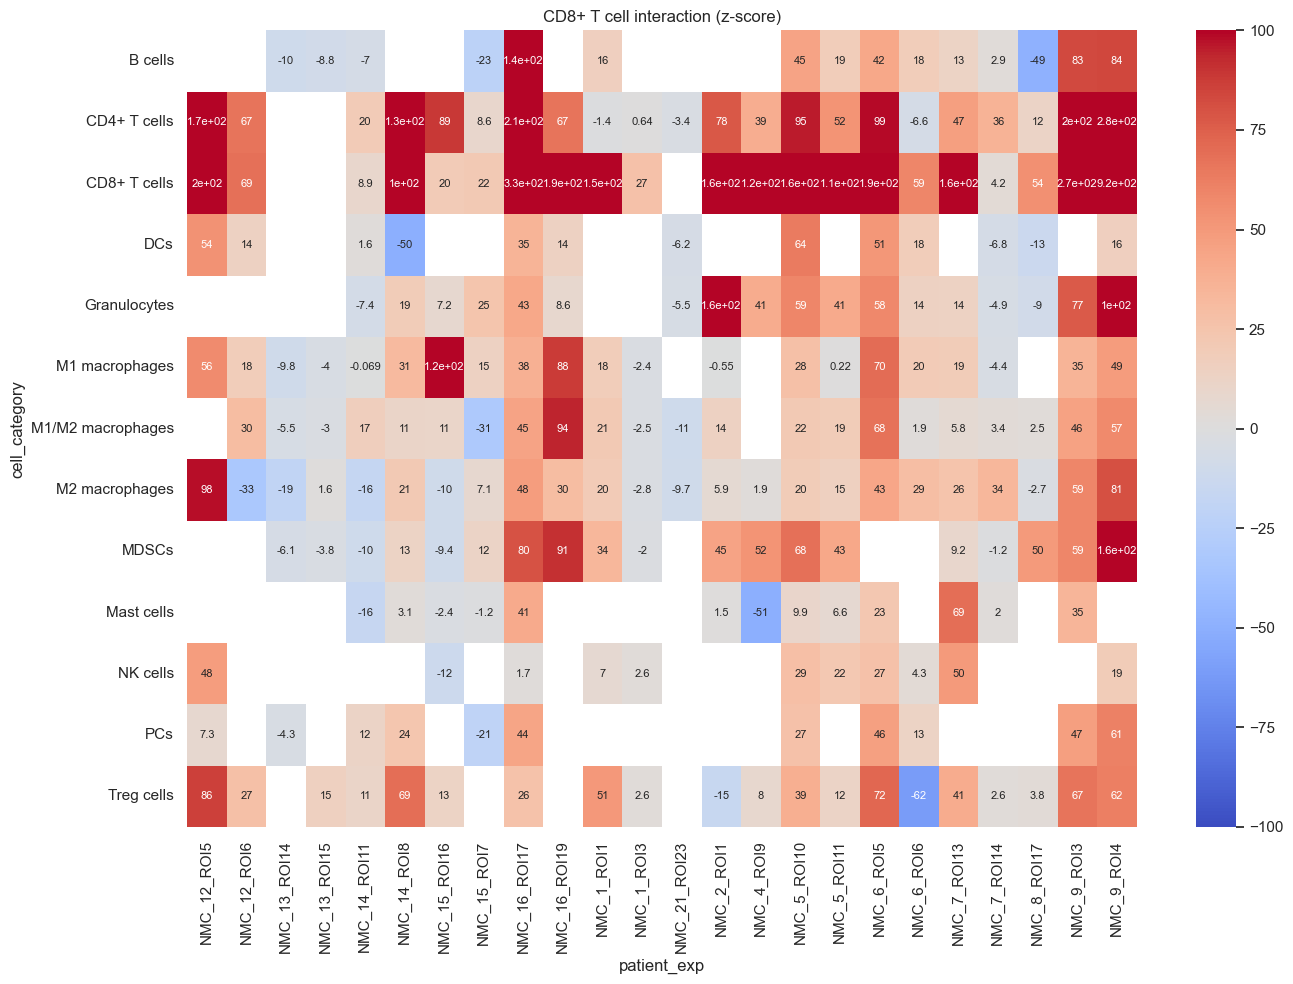

Text(0.5, 1.02, 'M2 macrophages CD8+ T cell interaction (z-score)')

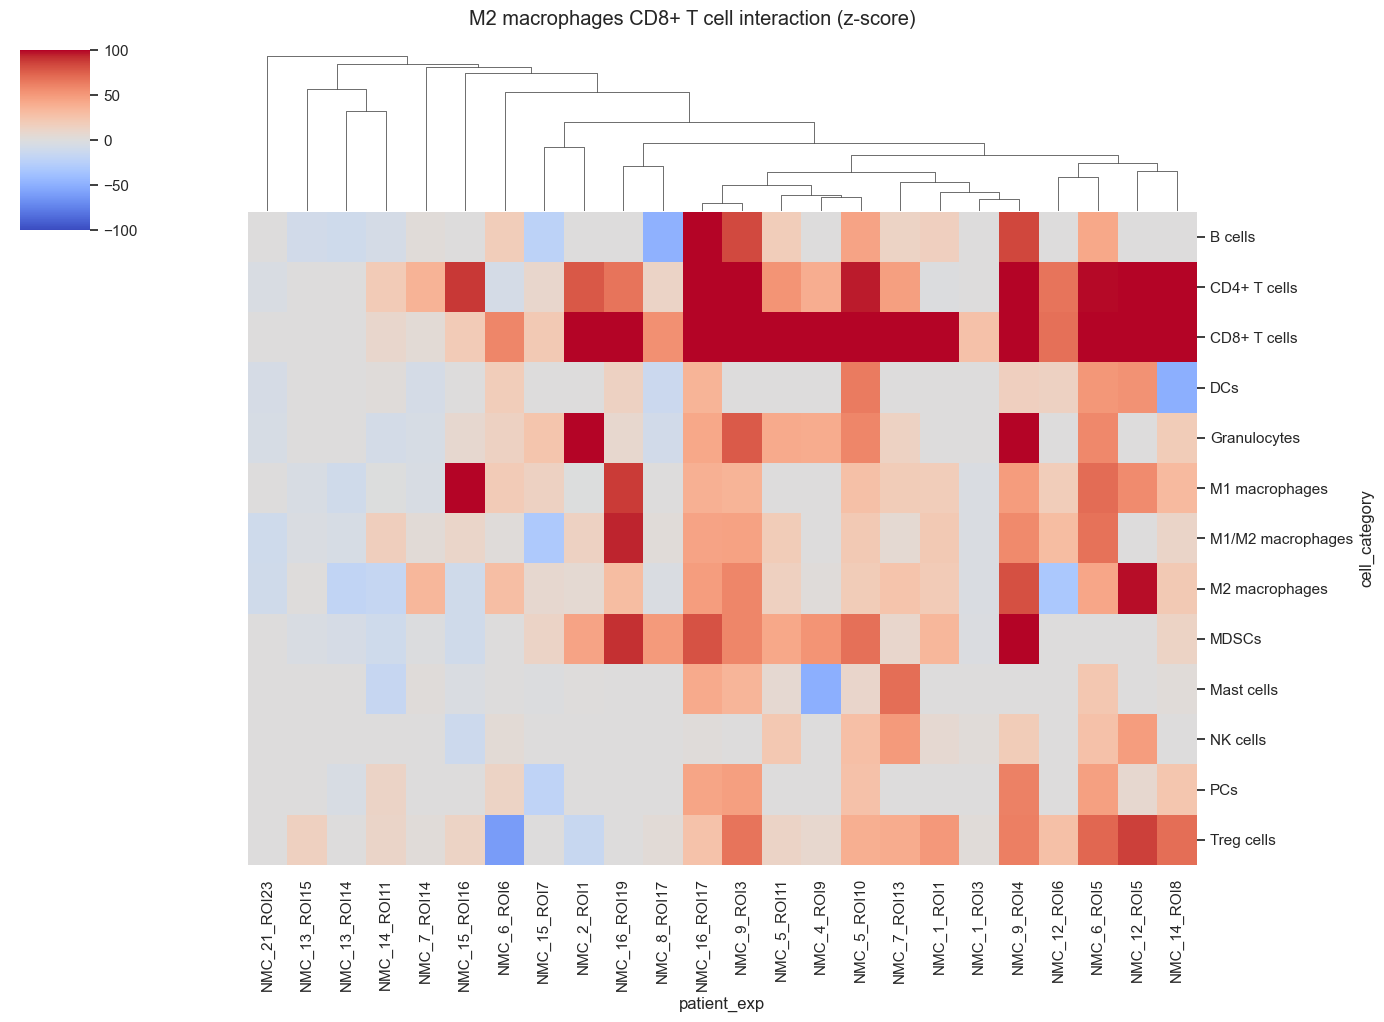

In [68]:
interactions = extract_interaction(adata,
                       selected_cell_type = "CD8+ T cells",
                       interaction_label = 'scimap_delaunay_conditional_zscore', 
                       direction = "to", 
                       cells_threshold = 30,
                       save_data=False,
                       excluded_cell_types = ["NFC", "Tumor cells", "Actin+ cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells"]
)

#save to csv
interactions.to_csv("/Users/jawadalaaedeen/Desktop/CD8_interactions.csv", index=False)

# interactions = interactions[interactions["cell_category"].isin(["MDSCs", "M2 macrophages", "Granulocytes"])]
#pivot wider
heatmap_df = interactions.pivot(index='cell_category', columns='patient_exp', values='zscore')

plt.figure(figsize=(14, 10))  # wide and short since 1 row
sns.heatmap(
   heatmap_df,
   cmap="coolwarm",
   center=0,
   annot=True,
   annot_kws={"size": 8},
   vmin=-100,
   vmax=100
)

plt.title("CD8+ T cell interaction (z-score)")
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

heatmap_df_filled = heatmap_df.fillna(0)

g = sns.clustermap(
    heatmap_df_filled,
    cmap="coolwarm",
    center=0,
    vmin=-100,
    vmax=100,
    col_cluster=True,
    row_cluster=False,
    metric="correlation",
    method="average",
    figsize=(14, 10)
)

g.fig.suptitle(f"{i} CD8+ T cell interaction (z-score)", y=1.02)

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/utils/interaction_scores_extract.py:37: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/utils/interaction_scores_extract.py:55: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_74624/865667279.py:20: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



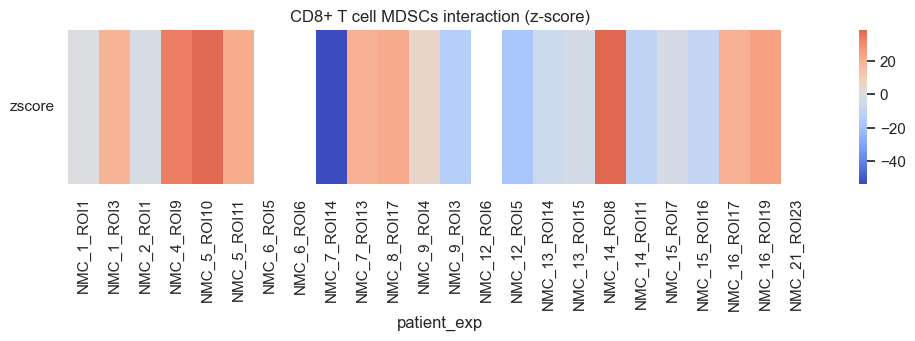

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/utils/interaction_scores_extract.py:37: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/utils/interaction_scores_extract.py:55: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_74624/865667279.py:20: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



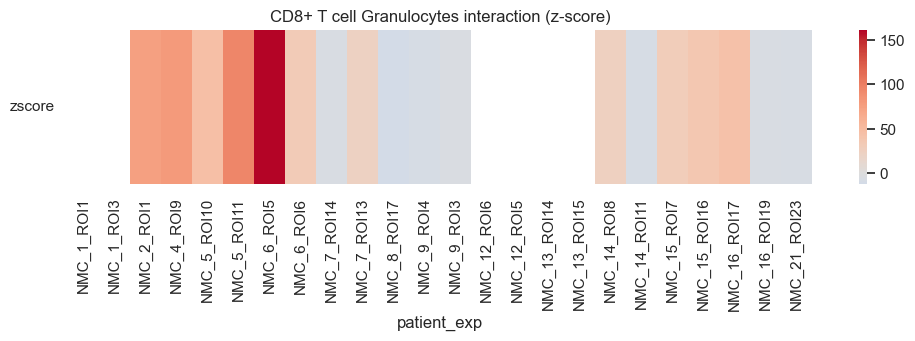

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/utils/interaction_scores_extract.py:37: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/utils/interaction_scores_extract.py:55: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_74624/865667279.py:20: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



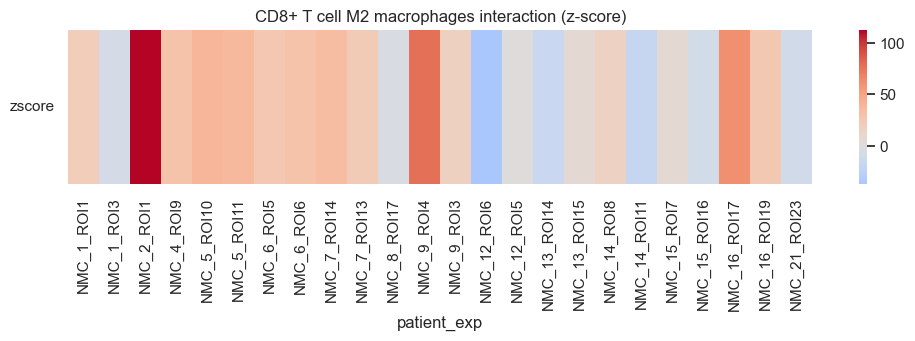

In [34]:
for i in ["MDSCs", "Granulocytes", "M2 macrophages"]:
    interactions = extract_interaction(adata,
                            selected_cell_type = "CD8+ T cells",
                            interaction_label = 'scimap_delaunay_conditional_zscore', 
                            direction = "from", 
                            cells_threshold = 15,
                            save_data=False)
    cd8_df = interactions[interactions["cell_category"] == i]
    heatmap_df = cd8_df.set_index("patient_exp")[["zscore"]].T
    plt.figure(figsize=(12, 2))  # wide and short since 1 row
    sns.heatmap(
        heatmap_df,
        cmap="coolwarm",
        center=0,
        annot=False
    )
    plt.title(f"CD8+ T cell {i} interaction (z-score)")
    plt.yticks(rotation=0)
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [191]:
#calculate distance between any cell type and CD8+ T cells
#Look at the spatial distance seperating any cell from CD8+ T cells
adata = sm.tl.spatial_distance (adata, phenotype='cell_category', x_coordinate="Cell Center X", y_coordinate="Cell Center Y", imageid='patient_exp')

# --- Data prep ---
distances = adata.uns['spatial_distance']
distances["cell_category"] = adata.obs['cell_category'].values
distances = distances.loc[:, ["cell_category", "MDSCs"]]
distances["MDSCs"] = distances["MDSCs"] * 0.17 # convert pixels to microns
# Order by median distance
order = (
    distances.groupby("cell_category")["MDSCs"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# Counts for each cell type
counts = distances["cell_category"].value_counts().reindex(order)

Processing Image: NMC_14_ROI11
Processing Image: NMC_15_ROI16
Processing Image: NMC_15_ROI7
Processing Image: NMC_1_ROI3
Processing Image: NMC_16_ROI19
Processing Image: NMC_2_ROI1
Processing Image: NMC_14_ROI8
Processing Image: NMC_16_ROI17
Processing Image: NMC_5_ROI10
Processing Image: NMC_8_ROI17
Processing Image: NMC_5_ROI11
Processing Image: NMC_6_ROI5
Processing Image: NMC_12_ROI5
Processing Image: NMC_13_ROI15
Processing Image: NMC_1_ROI1
Processing Image: NMC_9_ROI4
Processing Image: NMC_21_ROI23
Processing Image: NMC_9_ROI3
Processing Image: NMC_4_ROI9
Processing Image: NMC_13_ROI14
Processing Image: NMC_7_ROI14
Processing Image: NMC_7_ROI13
Processing Image: NMC_6_ROI6
Processing Image: NMC_12_ROI6


In [65]:
adata.uns['scimap_delaunay_conditional_zscore']

,phenotype,neighbour_phenotype,zscore_NMC_14_ROI11,pvalue_NMC_14_ROI11,cond_cells_percentage_NMC_14_ROI11,count_NMC_14_ROI11,zscore_NMC_15_ROI16,pvalue_NMC_15_ROI16,cond_cells_percentage_NMC_15_ROI16,count_NMC_15_ROI16,...,cond_cells_percentage_NMC_7_ROI13,count_NMC_7_ROI13,zscore_NMC_6_ROI6,pvalue_NMC_6_ROI6,cond_cells_percentage_NMC_6_ROI6,count_NMC_6_ROI6,zscore_NMC_12_ROI6,pvalue_NMC_12_ROI6,cond_cells_percentage_NMC_12_ROI6,count_NMC_12_ROI6
Actin+ cells-Actin+ cells,Actin+ cells,Actin+ cells,115.717155,0.000000e+00,0.940984,3.376804,102.195939,0.000000e+00,0.942826,3.663616,...,0.919431,3.533792,11.802119,3.806034e-32,0.671533,1.619565,34.437075,7.030846e-260,0.947020,3.174825
Actin+ cells-B cells,Actin+ cells,B cells,-0.315527,7.523619e-01,0.002342,1.000000,-7.584551,3.336409e-14,0.001079,0.000000,...,0.002633,1.200000,1.068289,2.853901e-01,0.040146,1.090909,-1.857219,6.328003e-02,0.013245,0.000000
Actin+ cells-CD4+ T cells,Actin+ cells,CD4+ T cells,19.089749,3.072392e-81,0.076815,1.335366,10.040847,1.008045e-23,0.012945,1.250000,...,0.012112,1.217391,-0.437821,6.615162e-01,0.043796,1.000000,2.821033,4.786932e-03,0.145695,1.227273
Actin+ cells-CD8+ T cells,Actin+ cells,CD8+ T cells,7.027629,2.100723e-12,0.023888,1.098039,3.373624,7.418551e-04,0.011866,1.090909,...,0.109005,1.154589,3.377796,7.306937e-04,0.142336,1.205128,5.105305,3.302613e-07,0.298013,1.333333
Actin+ cells-DCs,Actin+ cells,DCs,16.921973,3.098735e-64,0.012178,1.230769,NaN,NaN,NaN,NaN,...,NaN,0.000000,-23.492207,4.899909e-122,0.003650,0.000000,-0.027254,9.782570e-01,0.033113,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Tumor cells-NFC,Tumor cells,NFC,25.459660,5.518406e-143,0.075129,1.416259,1.949757,5.120504e-02,0.560228,1.883051,...,0.188605,1.714523,8.922273,4.568146e-19,0.170387,1.256010,6.653968,2.852949e-11,0.154257,1.168216
Tumor cells-NK cells,Tumor cells,NK cells,NaN,NaN,NaN,NaN,17.645036,1.111027e-69,0.008275,1.106557,...,0.002035,1.000000,6.045567,1.488855e-09,0.020684,1.069307,7.192125,6.379048e-13,0.002217,1.058824
Tumor cells-PCs,Tumor cells,PCs,11.381227,5.186456e-30,0.005077,1.072464,5.369316,7.903570e-08,0.003527,1.038462,...,NaN,NaN,28.747658,9.689147e-182,0.032972,1.397516,26.323860,1.022690e-152,0.003390,1.230769
Tumor cells-Treg cells,Tumor cells,Treg cells,7.792001,6.595607e-15,0.005666,1.051948,14.595849,2.984720e-48,0.013226,1.082051,...,0.013774,1.102273,7.573665,3.628398e-14,0.012288,1.083333,2.711666,6.694603e-03,0.008606,1.030303


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_56481/3920933766.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_56481/3920933766.py:5: FutureWarning:



The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.



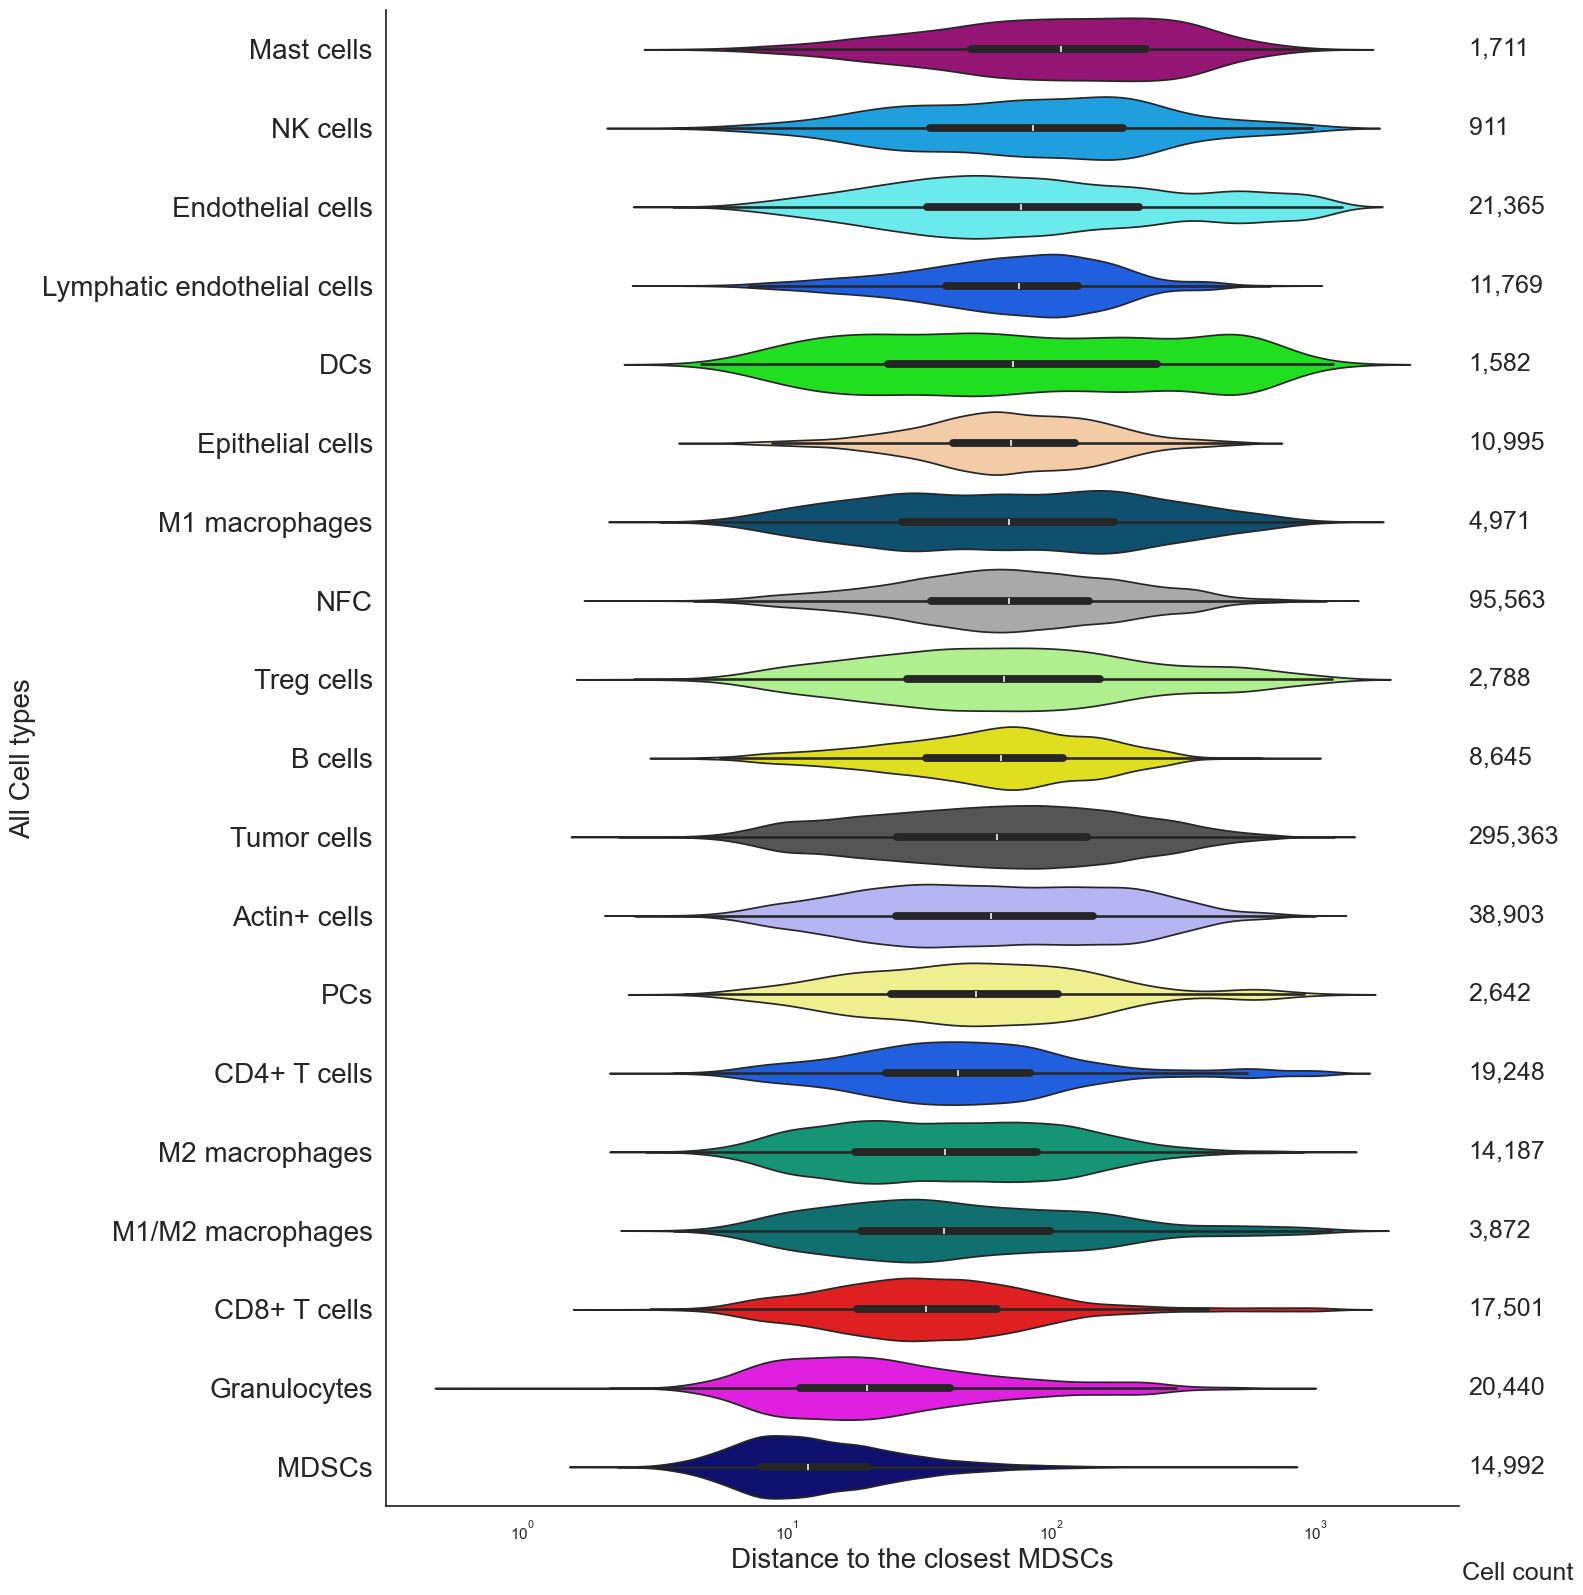

In [192]:
# --- Plot ---
fig, ax_violin = plt.subplots(figsize=(16, 16))

# Distance violinplot
sns.violinplot(
    data=distances,
    x="MDSCs",
    y="cell_category",
    order=order,
    palette=cell_category_color,   # <--- your custom colors here
    scale="width",
    ax=ax_violin,
    log_scale=True
)
#increase size of y-axis labels 
ax_violin.tick_params(axis='y', labelsize=20)
# Axis labels
ax_violin.set_xlabel(
    "Distance to the closest MDSCs",
    fontsize=20
)
ax_violin.set_ylabel(
    "All Cell types",
    fontsize=20
)

# Add counts on the right side
for i, cell_category in enumerate(order):
    count_val = counts[cell_category]
    ax_violin.text(
        x=ax_violin.get_xlim()[1] * 1.09,
        y=i,
        s=f"{count_val:,}",
        va="center",
        ha="left",
        fontfamily="Arial",
        fontsize = 18
    )

# Add label for counts (once)
ax_violin.text(
    x=ax_violin.get_xlim()[1] * 1.03,
    y=len(order) + 0.5,
    s="Cell count",
    va="bottom", ha="left",
    fontfamily="Arial", 
    fontsize = 18
)

# Remove right/top spines
sns.despine(ax=ax_violin, right=True, top=True)

#save svg figure
plt.tight_layout()
plt.show()

In [226]:
adata_filtered = adata[~adata.obs['patient_exp'].isin(["NMC_12_ROI6", "NMC_21_ROI23"])].copy()

In [227]:
#determining niches 
adata_filtered = sm.tl.spatial_lda(adata_filtered, method='radius', radius=170, label='spatial_lda', x_coordinate="Cell Center X", y_coordinate="Cell Center Y", imageid="patient_exp", phenotype="cell_category")


Processing: ['NMC_14_ROI11']
Identifying neighbours within 170 pixels of every cell
Processing: ['NMC_15_ROI16']
Identifying neighbours within 170 pixels of every cell
Processing: ['NMC_15_ROI7']
Identifying neighbours within 170 pixels of every cell
Processing: ['NMC_1_ROI3']
Identifying neighbours within 170 pixels of every cell
Processing: ['NMC_16_ROI19']
Identifying neighbours within 170 pixels of every cell
Processing: ['NMC_2_ROI1']
Identifying neighbours within 170 pixels of every cell
Processing: ['NMC_14_ROI8']
Identifying neighbours within 170 pixels of every cell
Processing: ['NMC_16_ROI17']
Identifying neighbours within 170 pixels of every cell
Processing: ['NMC_5_ROI10']
Identifying neighbours within 170 pixels of every cell
Processing: ['NMC_8_ROI17']
Identifying neighbours within 170 pixels of every cell
Processing: ['NMC_5_ROI11']
Identifying neighbours within 170 pixels of every cell
Processing: ['NMC_6_ROI5']
Identifying neighbours within 170 pixels of every cell
Pro

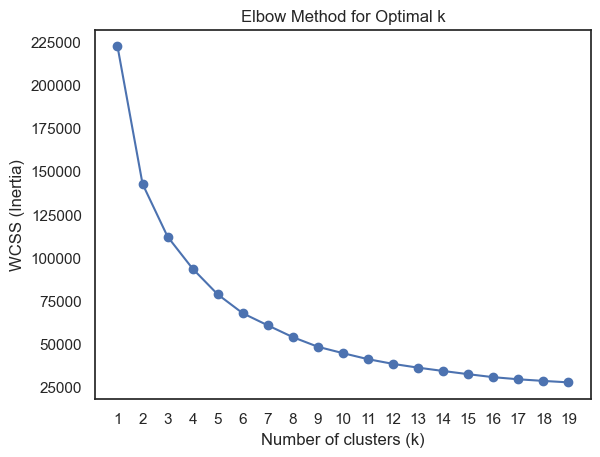

In [228]:
from sklearn.cluster import KMeans

# 1️⃣ Extract the representation used for clustering
X = adata_filtered.uns['spatial_lda']

# 2️⃣ Define k range
k_range = range(1, 20)

# 3️⃣ Compute WCSS (inertia)
wcss = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# 4️⃣ Plot elbow curve
plt.figure()
plt.plot(k_range, wcss, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.xticks(list(k_range))
plt.show()

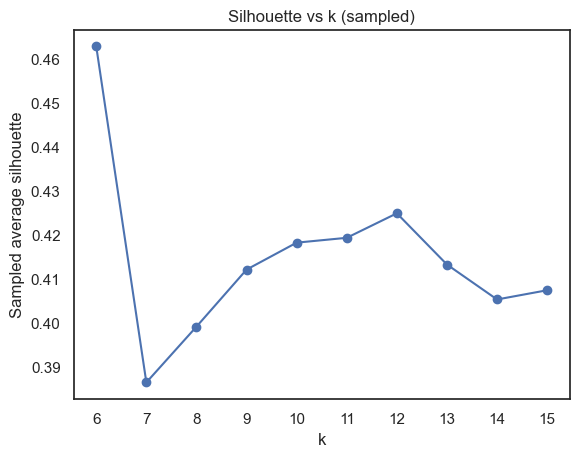

In [229]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = adata_filtered.uns["spatial_lda"]

k_range = [6,7,8,9,10,11,12,13,14,15]
sil_scores = []

for k in k_range:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)

    score = silhouette_score(
        X, labels,
        metric="euclidean",
        sample_size=20000,   # try 10k–50k
        random_state=42
    )
    sil_scores.append(score)

plt.figure()
plt.plot(list(k_range), sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Sampled average silhouette")
plt.title("Silhouette vs k (sampled)")
plt.xticks(list(k_range))
plt.show()


In [230]:
adata_filtered = sm.tl.spatial_cluster(adata_filtered, df_name='spatial_lda', method='kmeans', k=7, label='neigh_kmeans')

Kmeans clustering


In [13]:
myeloid_palette = {
    "MDSCs": "#332288",
    "M2 macrophages": "#66A61E",
    "M1 macrophages": "#00557F",
    "M1/M2 macrophages": "#BBCCEE",
    "DCs": "#E69F00",
    "Granulocytes": "#B85AA6",
    "Mast cells": "#8E006A",
}
lymphoid_palette = {
    "CD8+ T cells": "#B2182B",
    "CD4+ T cells": "#EF8A62",
    "Treg T cells": "#FFCCCC",
    "NK cells": "#0096FF",
    "B cells": "#E6C84F",
    "PCs": "#F4E58A",
}
non_immune_palette = {
    "Actin+ cells": "#B39DDB",
    "Endothelial cells": "#00BFC4",
    "Lymphatic endothelial cells": "#1F78B4",
    "Epithelial cells": "#C9B29B",
}
other_palette = {
    "Tumor cells": "#44AA99",
    "NFC": "#DDDDDD",
}
full_palette = {
    **myeloid_palette,
    **lymphoid_palette,
    **non_immune_palette,
    **other_palette,
}

In [232]:
sm.pl.stacked_barplot(adata_filtered, x_axis='neigh_kmeans', y_axis='cell_category', plot_tool='plotly', color_discrete_map = full_palette)

In [153]:
#Define niches by names
mapping = {
    0: "Tumor_NFC_niche",
    1: "Tumor_niche",
    2: "Lymphoid_immune_niche",
    3: "Lymphatic_NFC_niche",
    4: "Perivascular_niche",
    5: "",
    6: "Fibroblasts niche"
}

adata_filtered.obs['neigh_kmeans'] = adata_filtered.obs['neigh_kmeans'].astype(int)

adata_filtered.obs['kmeans_niche'] = adata_filtered.obs['neigh_kmeans'].map(mapping)

In [178]:
#plot distribution of niches per patient 
sm.pl.stacked_barplot(adata_filtered, x_axis='patient_ID', y_axis='kmeans_niche', plot_tool='plotly')

In [220]:
import pandas as pd
import plotly.express as px
import plotly.io as pio


def plotly_scatter(adata, phenotype, image_id, x='X_centroid', y='Y_centroid', size=2, id_col='patient_exp', **kwargs):
    ad = adata[adata.obs[id_col] == image_id].copy()

    data = pd.DataFrame({
        'x': ad.obs[x].values,
        'y': ad.obs[y].values,
        'col': ad.obs[phenotype].values
    }).sort_values('col')

    fig = px.scatter(data, x="x", y="y", color="col", **kwargs)
    fig.update_traces(marker=dict(size=size), selector=dict(mode='markers'), hoverlabel=dict(namelength=-1))
    fig.update_yaxes(autorange="reversed", tickformat='g')
    fig.update_xaxes(tickformat='g')
    fig.update_layout(plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')

    fig.update_layout(title_text=f'{id_col}: {image_id}', title_x=0.5, title_font_size=20)
    fig.show()

In [222]:
def plotly_cells(adata,image_id="patient_exp",x='Cell Center X',y='Cell Center Y', phenotype = "cell_type", size=2, color_map=None, **kwargs):
    patient_exp = adata.obs[image_id].unique()[0]
    data = pd.DataFrame({'x':adata.obs[x], 'y':adata.obs[y],'col': adata.obs[phenotype]})
    data = data.sort_values(by=['col'])
    fig = px.scatter(data, x="x", y="y", color="col", **kwargs)
    scatter_kwargs = dict(x="x", y="y", color="col")
    if color_map is not None:
        scatter_kwargs["color_discrete_map"] = color_map  # Only if provided
    fig = px.scatter(data, **scatter_kwargs, **kwargs)
    fig.update_traces(marker=dict(size=size),selector=dict(mode='markers'),hoverlabel = dict(namelength = -1))
    fig.update_yaxes(autorange="reversed", tickformat='g')
    fig.update_xaxes(tickformat='g')
    fig.update_layout({'plot_bgcolor': 'rgba(0, 0, 0, 0)','paper_bgcolor': 'rgba(0, 0, 0, 0)'})
    fig.update_layout(title_text=f'Patient: {patient_exp} - {adata.obs["survival_time_months"].unique()[0]} months', title_x=0.5, title_font_size=20)
    fig.show()

In [224]:
for i in adata_filtered.obs.patient_exp.unique():
    plotly_scatter(adata_filtered, phenotype="kmeans_niche", image_id=i, id_col="patient_exp", size=6, x= "Cell Center X", y="Cell Center Y")
    adata_select = adata_filtered[adata_filtered.obs["patient_exp"] == i]
    plotly_cells(adata_select, size = 6, phenotype="cell_category", color_map=full_palette)

In [4]:
adata = ad.read("/Users/jawadalaaedeen/Desktop/adata_clustered.h5ad")

/Users/jawadalaaedeen/Desktop/PhD/NMC/NMC_spatial/spatial_analysis/nmc_spatial_env/lib/python3.10/site-packages/anndata/__init__.py:55: FutureWarning:

`anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.



In [8]:
from cozipy.neighbors import knn_graph, radius_graph, delaunay_graph
from cozipy.nep_cozi import run_cozi

In [117]:
import numpy as np
from scipy.spatial import Delaunay
from scipy.sparse import coo_matrix

def delaunay_graph(coords, labels=None, remove_intra=False):
    """
    Delaunay adjacency using SciPy.
    Produces directional edges (both i->j and j->i) in COO format.

    Parameters
    ----------
    coords : np.ndarray
        Array of shape (n_cells, 2)
    labels : array-like, optional
        Cluster labels aligned with coords (length n_cells)
    remove_intra : bool
        If True, remove edges between cells of the same cluster.
    """

    tri = Delaunay(coords)
    simplices = tri.simplices

    edges = set()
    for s in simplices:
        a, b, c = s
        edges.add((a, b))
        edges.add((b, a))
        edges.add((b, c))
        edges.add((c, b))
        edges.add((a, c))
        edges.add((c, a))

    # 🔹 Remove intra-cluster edges if requested
    if remove_intra:
        if labels is None:
            raise ValueError("labels must be provided if remove_intra=True")

        labels = np.asarray(labels)
        edges = {
            (i, j) for (i, j) in edges
            if labels[i] != labels[j]
        }

    rows = [e[0] for e in edges]
    cols = [e[1] for e in edges]
    data = np.ones(len(rows), dtype=int)
    n = coords.shape[0]

    return coo_matrix((data, (rows, cols)), shape=(n, n))

In [118]:
def _encode_labels(labels):
    labels = pd.Series(labels, dtype="category")
    codes = labels.cat.codes.to_numpy()
    categories = labels.cat.categories.to_list()
    return codes, categories


def _compute_pair_counts_and_denominators(adj, labels_int, n_types):
    """
    Returns:
        counts[A, B] = total edges from A to B
        denom[A, B]  = number of cells of type A having >=1 neighbor of type B
    
    The indices fed to np.bincount are calculated using 64-bit integers 
    to prevent overflow on large numbers of cell types (n_types).
    """
    i, j = adj.row, adj.col
    labels_int = np.asarray(labels_int)

    if n_types == 0 or labels_int.size == 0:
        return np.zeros((0, 0), dtype=int), np.zeros((0, 0), dtype=int)

    # Use 64-bit integers for the calculation that previously overflowed a 32-bit integer.
    labels_int_64 = labels_int.astype(np.int64)
    n_types_64 = np.int64(n_types)

    counts = np.bincount(
        labels_int_64[i] * n_types_64 + labels_int_64[j],
        minlength=n_types_64 * n_types_64
    ).reshape(n_types, n_types)

    neigh_labels = labels_int[j]
    src_labels = labels_int[i]

    cell_has_neighbor_type = np.zeros((len(labels_int), n_types), dtype=bool)
    cell_has_neighbor_type[i, neigh_labels] = True

    denom = np.zeros((n_types, n_types), dtype=int)
    for A in range(n_types):
        maskA = (labels_int == A)
        denom[A] = cell_has_neighbor_type[maskA].sum(axis=0)

    return counts, denom


def nep_analysis(adj,
                 labels,
                 n_permutations=1000,
                 random_state=None,
                 return_df=True,
                 fixed_type=None):
    """
    NEP analysis with conditional ratios and z-scores.

    Parameters
    ----------
    STILL UNDER DEVELOPMENT IF MAKES SENSE
    fixed_type : str or int or None
        If provided, this cell type will remain fixed in permutations while
        all other cell types are shuffled.
    """
    rng = np.random.default_rng(random_state)
    labels_int, label_names = _encode_labels(labels)
    n_types = len(label_names)  # SAFER calculation of n_types

    # Ensure n_types > 0 before proceeding
    if n_types == 0:
        if return_df:
            # Return empty dataframes if there are no cell types
            idx = []
            return {
                "cond_ratio": pd.DataFrame([], index=idx, columns=idx),
                "zscore": pd.DataFrame([], index=idx, columns=idx),
            }
        else:
            return {
                "cond_ratio": np.array([]).reshape(0, 0),
                "zscore": np.array([]).reshape(0, 0),
            }

    # Pass the safely calculated n_types
    obs_counts, obs_denom = _compute_pair_counts_and_denominators(
        adj, labels_int, n_types)
    obs_norm = obs_counts / np.maximum(obs_denom, 1)

    cond_ratio = np.zeros((n_types, n_types), float)
    for A in range(n_types):
        total_A = (labels_int == A).sum()
        cond_ratio[A] = obs_denom[A] / max(total_A, 1)

    perm_norm = np.zeros((n_permutations, n_types, n_types), float)

    # convert fixed_type name -> integer index if needed
    if fixed_type is not None and isinstance(fixed_type, str):
        fixed_type = label_names.index(fixed_type)

    for k in range(n_permutations):
        if fixed_type is None:
            perm = rng.permutation(labels_int)
        else:
            # Mask cells to remain unchanged vs permuted
            fixed_mask = labels_int == fixed_type
            other_mask = ~fixed_mask

            # Copy original labels then permute only others
            perm = labels_int.copy()
            perm[other_mask] = rng.permutation(labels_int[other_mask])

        # Pass the safely calculated n_types
        c, d = _compute_pair_counts_and_denominators(adj, perm, n_types)
        perm_norm[k] = c / np.maximum(d, 1)

    expected = perm_norm.mean(axis=0)
    std = perm_norm.std(axis=0) + 1e-6
    z = (obs_norm - expected) / std

    if return_df:
        idx = label_names
        z_df = pd.DataFrame(z, index=idx, columns=idx)
        cond_df = pd.DataFrame(cond_ratio, index=idx, columns=idx)
        return {
            "cond_ratio": cond_df,
            "zscore": z_df,
        }
    else:
        return {
            "cond_ratio": cond_ratio,
            "zscore": z,
        }

In [122]:
def run_cozi(
    coords,
    labels,
    nbh_def="delaunay",
    n_permutations=100,
    random_state=None,
    fixed_type=None,
    intra_links=False,
):
    """
    Runs NEP analysis with specified neighborhood definition.
    Accepts string labels.
    """
    # build adjacency
    if nbh_def == "delaunay" and intra_links is False:
        adj = delaunay_graph(coords)
    elif nbh_def == "delaunay" and intra_links is True:
        adj = delaunay_graph(coords, labels=labels, remove_intra=True)
    else:
        raise ValueError(f"Unknown neighborhood definition: {nbh_def}")

    # run NEP
    return nep_analysis(
        adj,
        labels,
        n_permutations=n_permutations,
        random_state=random_state,
        fixed_type=fixed_type,
    )

#Different COZI approach

In [139]:
def nep_analysis(
    adj,
    labels,
    n_permutations=1000,
    random_state=None,
    return_df=True,
    fixed_type=None,
    intra_links=False,   # <-- key flag
):
    rng = np.random.default_rng(random_state)
    labels_int, label_names = _encode_labels(labels)
    n_types = len(label_names)

    if n_types == 0:
        out = {"cond_ratio": np.zeros((0,0)), "zscore": np.zeros((0,0))}
        if return_df:
            return {"cond_ratio": pd.DataFrame(), "zscore": pd.DataFrame()}
        return out

    obs_counts, obs_denom = _compute_pair_counts_and_denominators(
        adj, labels_int, n_types, remove_intra=remove_intra
    )
    obs_norm = obs_counts / np.maximum(obs_denom, 1)

    # fraction of A cells that touch at least one B
    cond_ratio = np.zeros((n_types, n_types), float)
    for A in range(n_types):
        total_A = (labels_int == A).sum()
        cond_ratio[A] = obs_denom[A] / max(total_A, 1)

    perm_norm = np.zeros((n_permutations, n_types, n_types), float)

    if fixed_type is not None and isinstance(fixed_type, str):
        fixed_type = label_names.index(fixed_type)

    for k in range(n_permutations):
        if fixed_type is None:
            perm = rng.permutation(labels_int)
        else:
            fixed_mask = labels_int == fixed_type
            other_mask = ~fixed_mask
            perm = labels_int.copy()
            perm[other_mask] = rng.permutation(labels_int[other_mask])

        # IMPORTANT: intra-removal uses *perm* labels now (consistent null)
        c, d = _compute_pair_counts_and_denominators(
            adj, perm, n_types, remove_intra=remove_intra
        )
        perm_norm[k] = c / np.maximum(d, 1)

    expected = perm_norm.mean(axis=0)
    std = perm_norm.std(axis=0) + 1e-6
    z = (obs_norm - expected) / std

    if return_df:
        idx = label_names
        return {
            "cond_ratio": pd.DataFrame(cond_ratio, index=idx, columns=idx),
            "zscore": pd.DataFrame(z, index=idx, columns=idx),
        }
    return {"cond_ratio": cond_ratio, "zscore": z}

In [140]:
def run_cozi(coords, labels, n_permutations=1000, random_state=None, fixed_type=None, remove_intra=False):
    adj = delaunay_graph(coords)
    return nep_analysis(
        adj,
        labels,
        n_permutations=n_permutations,
        random_state=random_state,
        fixed_type=fixed_type,
        remove_intra=remove_intra,
    )

## THE ACTUAL COZI

In [185]:
adata = sc.read_h5ad("/Users/jawadalaaedeen/Desktop/adata_spatial_final.h5ad")

In [186]:
import cozipy as czp 

In [393]:
import pandas as pd

all_long = []

for pt in adata.obs["patient_exp"].unique():
    adata_select = adata[adata.obs["patient_exp"] == pt].copy()

    results = czp.run_cozi(
        coords=adata_select.obs[["Cell Center X", "Cell Center Y"]].values,
        labels=adata_select.obs["cell_category"].values,
        nbh_def="delaunay",
        n_permutations=100,
        random_state=42,
            )

    # results["cond_ratio"] and results["zscore"] are DataFrames (because return_df=True by default)
    cond_df = results["cond_ratio"].copy()
    z_df = results["zscore"].copy()

    # Long format
    cond_long = (
        cond_df.stack(dropna=False)
        .rename("cond_ratio")
        .reset_index()
        .rename(columns={"level_0": "celltype_A", "level_1": "celltype_B"})
    )
    z_long = (
        z_df.stack(dropna=False)
        .rename("zscore")
        .reset_index()
        .rename(columns={"level_0": "celltype_A", "level_1": "celltype_B"})
    )

    long_df = cond_long.merge(z_long, on=["celltype_A", "celltype_B"], how="inner")

    # Conditional % (0–100)
    long_df["cond_percent"] = 100.0 * long_df["cond_ratio"]

    # Cell pair label + patient
    long_df["cell_pair"] = long_df["celltype_A"].astype(str) + "-" + long_df["celltype_B"].astype(str)
    long_df["patient_exp"] = pt

    all_long.append(long_df[["patient_exp", "celltype_A", "celltype_B", "cell_pair", "zscore", "cond_percent"]])

final_table = pd.concat(all_long, ignore_index=True)
#total number of cells and total number of tumor cells per sample
total_cells = adata.obs.groupby("patient_exp").size().reset_index(name="total_cells")
tumor_cells = adata.obs[adata.obs["cell_category"] == "Tumor cells"].groupby("patient_exp").size().reset_index(name="tumor_cells")
final_table = final_table.merge(total_cells, on="patient_exp", how="left")
final_table = final_table.merge(tumor_cells, on="patient_exp", how="left")

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_66977/3530576143.py:22: FutureWarning:

The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_66977/3530576143.py:28: FutureWarning:

The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_66977/3530576143.py:22: FutureWarning:

The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and 

In [394]:
final_table["zscore_normalized"] = final_table["zscore"] / np.sqrt(final_table["total_cells"])

In [395]:
#keep only immune cells
immune_cells = [
    "CD4+ T cells",
    "CD8+ T cells",
    "Treg T cells",
    "NK cells",
    "B cells",
    "PCs",
    "DCs",
    "Granulocytes",
    "Mast cells",
    "MDSCs",
    "M1 macrophages",
    "M2 macrophages",
    "M1/M2 macrophages"
]
immune_interactions = final_table[
    (final_table["celltype_A"].isin(immune_cells)) &
    (final_table["celltype_B"].isin(immune_cells))
].copy()

#calculate numner of celltype_A and celltype_B per patient_exp
celltype_counts = adata.obs.groupby(["patient_exp", "cell_category"]).size().reset_index(name="count")
celltype_counts = celltype_counts[celltype_counts["cell_category"].isin(immune_cells)].copy()
celltype_counts = celltype_counts.rename(columns={"count": "celltype_A_count", "cell_category": "celltype_A"})
#left join immune_interactions with celltype_counts on patient_exp and celltype_A
immune_interactions = immune_interactions.merge(celltype_counts, on=["patient_exp", "celltype_A"], how="left")
celltype_counts = celltype_counts.rename(columns={"celltype_A": "celltype_B", "celltype_A_count": "celltype_B_count"})
#left join immune_interactions with celltype_counts on patient_exp and celltype_B
immune_interactions = immune_interactions.merge(celltype_counts, on=["patient_exp", "celltype_B"], how="left")
#make patient_ID column from patient_exp
immune_interactions["patient_ID"] = immune_interactions["patient_exp"].str.replace(r"_ROI.*$", "", regex=True)
#make it NUT_ instead of NMC_
immune_interactions["patient_ID"] = immune_interactions["patient_ID"].str.replace(r"^NMC_", "NUT_", regex=True)
immune_interactions

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_66977/3462485088.py:23: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,patient_exp,celltype_A,celltype_B,cell_pair,zscore,cond_percent,total_cells,tumor_cells,zscore_normalized,celltype_A_count,celltype_B_count,patient_ID
0,NMC_1_ROI1,B cells,B cells,B cells-B cells,2.941854,38.235294,7738,3455,0.033443,34,34,NUT_1
1,NMC_1_ROI1,B cells,CD4+ T cells,B cells-CD4+ T cells,0.670279,2.941176,7738,3455,0.007620,34,40,NUT_1
2,NMC_1_ROI1,B cells,CD8+ T cells,B cells-CD8+ T cells,1.471191,17.647059,7738,3455,0.016725,34,150,NUT_1
3,NMC_1_ROI1,B cells,DCs,B cells-DCs,-0.229415,0.000000,7738,3455,-0.002608,34,2,NUT_1
4,NMC_1_ROI1,B cells,Granulocytes,B cells-Granulocytes,2.708004,2.941176,7738,3455,0.030785,34,5,NUT_1
...,...,...,...,...,...,...,...,...,...,...,...,...
3463,NMC_16_ROI19,Treg T cells,MDSCs,Treg T cells-MDSCs,0.088027,68.000000,17398,10677,0.000667,25,1967,NUT_16
3464,NMC_16_ROI19,Treg T cells,Mast cells,Treg T cells-Mast cells,-0.229415,0.000000,17398,10677,-0.001739,25,7,NUT_16
3465,NMC_16_ROI19,Treg T cells,NK cells,Treg T cells-NK cells,5.686207,4.000000,17398,10677,0.043110,25,3,NUT_16
3466,NMC_16_ROI19,Treg T cells,PCs,Treg T cells-PCs,-0.229415,0.000000,17398,10677,-0.001739,25,8,NUT_16


In [461]:
#extract from adata.obs["Survival after diagnosis of malignacy"] string the number before "months" or "Months" and convert to numeric, 
#store in new column "survival_time_months"
adata.obs["survival_time_months"] = adata.obs["Survival after diagnosis of malignacy"].str.extract(r"(\d+)\s*[mM]onths").astype(float)
survival_data = adata.obs[["patient_ID", "survival_time_months", "tumor_site"]].drop_duplicates().reset_index(drop=True)
#make it NUT_ instead of NMC_
survival_data["patient_ID"] = survival_data["patient_ID"].str.replace(r"^NMC_", "NUT_", regex=True)
survival_data["patient_ID"] = survival_data["patient_ID"].str.replace(r"^NMC_", "NUT_", regex=True)
#all of survival_data["event"] = 1 except the first NMC_1 is 0 
survival_data["event"] = 1
survival_data.loc[survival_data["patient_ID"] == "NUT_1", "event"] = 0
# survival_data = survival_data.merge(mdscs[["patient_ID", "mdscs_group"]], on="patient_ID", how="left")
survival_data["tumor_site"] = pd.Categorical(survival_data["tumor_site"], categories=["Lung", "Head and Neck", "Extrahepatic"], ordered=True)
survival_data

,patient_ID,survival_time_months,tumor_site,event
0,NUT_1,170.0,Head and Neck,0
1,NUT_2,3.0,Lung,1
2,NUT_4,4.0,Lung,1
3,NUT_5,9.0,Head and Neck,1
4,NUT_6,7.0,Lung,1
5,NUT_7,10.0,Lung,1
6,NUT_8,4.0,Lung,1
7,NUT_9,2.0,Lung,1
8,NUT_12,48.0,Head and Neck,1
9,NUT_13,6.0,Lung,1


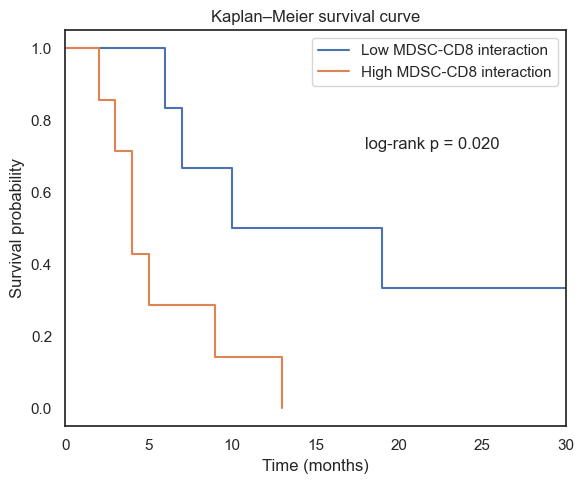

In [796]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

plt.figure(figsize=(6,5))

kmf = KaplanMeierFitter()

for group in survival_data["mdscs_group"].unique():
    mask = survival_data["mdscs_group"] == group
    kmf.fit(
        survival_data.loc[mask, "survival_time_months"],
        event_observed=survival_data.loc[mask, "event"],
        label=group
    )
    kmf.plot_survival_function(ci_show=False)

group_high = survival_data[survival_data["mdscs_group"] == "High MDSC-CD8 interaction"]
group_low = survival_data[survival_data["mdscs_group"] == "Low MDSC-CD8 interaction"]

result = logrank_test(
    group_high["survival_time_months"],
    group_low["survival_time_months"],
    event_observed_A=group_high["event"],
    event_observed_B=group_low["event"]
)

plt.text(0.6, 0.7, f"log-rank p = {result.p_value:.3f}", transform=plt.gca().transAxes)
plt.xlim(0, 30)
plt.xlabel("Time (months)")
plt.ylabel("Survival probability")
plt.title("Kaplan–Meier survival curve")

plt.savefig("/Users/jawadalaaedeen/Desktop/images_for_figures/figure_4/MDSC_CD8_interaction_survival_plot.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

In [788]:
#amount of Granulocytes, amount of MDSCs, amount of M2 macrophages, amount of CD8+ T cells, Granulocyte&MDSCs over CD8+ T cells ratio.. Macrophages over CD8+ T cells, Myeloid/Lymphoid, #Interaction with CD8+ T cells
#amount of all cell types
#get the count of cell types
cell_counts = adata.obs.groupby(["patient_ID", "cell_category"]).size().unstack().fillna(0)
cell_counts["patient_ID"] = cell_counts.index
cell_counts = cell_counts.reset_index(drop=True)
cell_counts.columns.name = None
cell_counts["total_cells"] = cell_counts.iloc[:,:-1].sum(axis=1)
cell_counts["Macrophages"] = cell_counts.loc[:, ["M1 macrophages", "M1/M2 macrophages", "M2 macrophages"]].sum(axis=1)
cell_counts["M2 macrophages"] = cell_counts.loc[:, ["M1/M2 macrophages", "M2 macrophages"]].sum(axis = 1)
cell_counts = cell_counts[["patient_ID", "CD8+ T cells","Granulocytes", "Macrophages", "M2 macrophages", "MDSCs", "total_cells"]]
cell_counts["Gran_M2"] = cell_counts["Granulocytes"] / cell_counts["M2 macrophages"]
cell_counts["Gran_T"] = cell_counts["Granulocytes"] / cell_counts["CD8+ T cells"]
cell_counts["MDSCs_T"] = cell_counts["MDSCs"] / cell_counts["CD8+ T cells"]
cell_counts["M2_T"] = cell_counts["M2 macrophages"] / cell_counts["CD8+ T cells"]
cell_counts["Gran_prop"] = cell_counts["Granulocytes"] / cell_counts["total_cells"]
cell_counts["MDSCs_prop"] = cell_counts["MDSCs"] / cell_counts["total_cells"]
cell_counts["M2_prop"] = cell_counts["M2 macrophages"] / cell_counts["total_cells"]
cell_counts = cell_counts[["patient_ID", "Gran_prop", "MDSCs_prop", "M2_prop", "Gran_M2", "Gran_T", "MDSCs_T", "M2_T"]]

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_19094/3574784445.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [789]:
survival_groups = pd.DataFrame({"patient_ID" : cell_counts["patient_ID"]})
for cl in ["Gran_M2", "Gran_T", "MDSCs_T", "M2_T"]:
    survival_groups[cl] = [f"High {cl}" if x > 1 else f"Low {cl}" for x in cell_counts[cl]]
survival_groups = survival_groups.merge(survival_data)
survival_groups

,patient_ID,Gran_M2,Gran_T,MDSCs_T,M2_T,survival_time_months,event,mdscs_group
0,NMC_1,Low Gran_M2,Low Gran_T,High MDSCs_T,High M2_T,170.0,0,Low MDSC-CD8 interaction
1,NMC_2,High Gran_M2,High Gran_T,High MDSCs_T,High M2_T,3.0,1,High MDSC-CD8 interaction
2,NMC_4,High Gran_M2,High Gran_T,High MDSCs_T,Low M2_T,4.0,1,High MDSC-CD8 interaction
3,NMC_5,High Gran_M2,High Gran_T,High MDSCs_T,High M2_T,9.0,1,High MDSC-CD8 interaction
4,NMC_6,Low Gran_M2,Low Gran_T,Low MDSCs_T,High M2_T,7.0,1,Low MDSC-CD8 interaction
5,NMC_7,Low Gran_M2,Low Gran_T,High MDSCs_T,High M2_T,10.0,1,Low MDSC-CD8 interaction
6,NMC_8,High Gran_M2,High Gran_T,High MDSCs_T,High M2_T,4.0,1,High MDSC-CD8 interaction
7,NMC_9,High Gran_M2,Low Gran_T,Low MDSCs_T,Low M2_T,2.0,1,High MDSC-CD8 interaction
8,NMC_12,Low Gran_M2,Low Gran_T,Low MDSCs_T,High M2_T,48.0,1,Low MDSC-CD8 interaction
9,NMC_13,Low Gran_M2,Low Gran_T,High MDSCs_T,High M2_T,6.0,1,Low MDSC-CD8 interaction


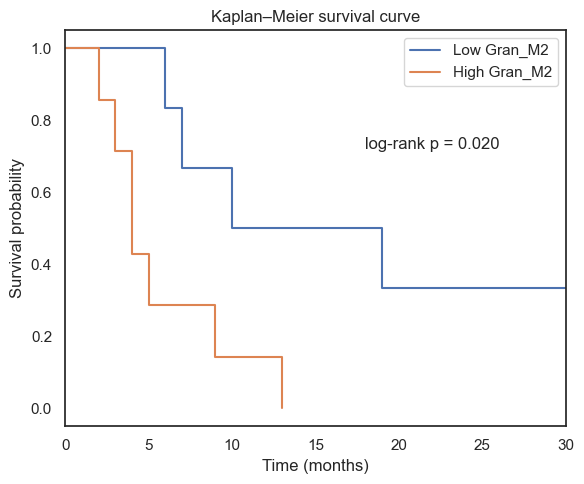

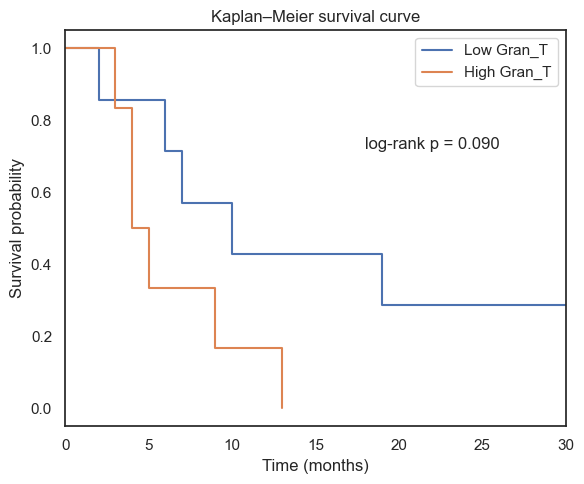

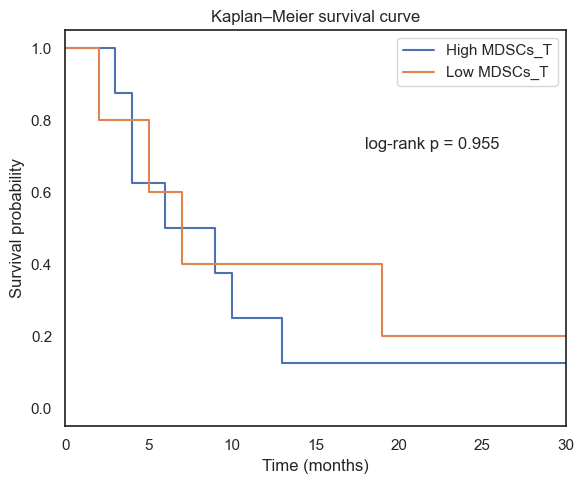

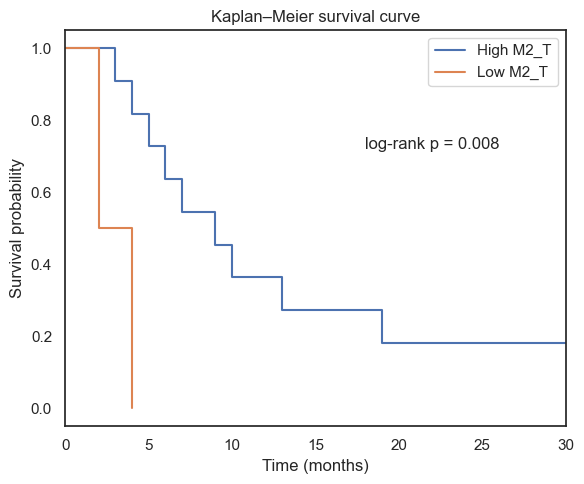

In [793]:
for cl in ["Gran_M2", "Gran_T", "MDSCs_T", "M2_T"]:

    plt.figure(figsize=(6,5))
    
    kmf = KaplanMeierFitter()
    
    for group in survival_groups[cl].unique():
        mask = survival_groups[cl] == group
        kmf.fit(
            survival_groups.loc[mask, "survival_time_months"],
            event_observed=survival_groups.loc[mask, "event"],
            label=group
        )
        kmf.plot_survival_function(ci_show=False)
    
    group_high = survival_groups[survival_groups[cl] == f"High {cl}"]
    group_low = survival_groups[survival_groups[cl] == f"Low {cl}"]
    
    result = logrank_test(
        group_high["survival_time_months"],
        group_low["survival_time_months"],
        event_observed_A=group_high["event"],
        event_observed_B=group_low["event"]
    )
    
    plt.text(0.6, 0.7, f"log-rank p = {result.p_value:.3f}", transform=plt.gca().transAxes)
    plt.xlim(0, 30)
    plt.xlabel("Time (months)")
    plt.ylabel("Survival probability")
    plt.title("Kaplan–Meier survival curve")
    plt.savefig(f"/Users/jawadalaaedeen/Desktop/images_for_figures/figure_4/{cl}_survival_plot.png", dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()



In [251]:
immune_interactions.to_csv("/Users/jawadalaaedeen/Desktop/immune_interactions.csv", index=False)

In [470]:
def cozi_dotplot(
    res,
    column_name="celltype_A",
    zscore_col="zscore",
    patient_col="patient_exp",    
    celltype_order=None,
    figsize=None,
    save_path=None,
    size_scale=3,
    max_dot_size=250,
    min_dot_size=8,
    vmin=None,
    vcenter=0,
    vmax=None,
    survival_data=None,
    survival_col="survival",
    tumor_site_col = "tumor_site",
    tumor_site_colors = tumor_site_colors,
    survival_ylim=None,  
    show_legend = True,       
):

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.colors import TwoSlopeNorm
    from matplotlib.gridspec import GridSpec

    df = res.copy()

    # use flexible patient column
    df = df[[patient_col, column_name, zscore_col, "cond_percent"]].copy()

    df[patient_col] = df[patient_col].astype(str)
    df[column_name] = df[column_name].astype(str)
    df[zscore_col] = pd.to_numeric(df[zscore_col], errors="coerce")
    df["cond_percent"] = pd.to_numeric(df["cond_percent"], errors="coerce")

    patients = df[patient_col].drop_duplicates().tolist()

    if celltype_order is not None:
        celltypes = [ct for ct in celltype_order if ct in df[column_name].unique()]
    else:
        celltypes = df[column_name].drop_duplicates().tolist()

    # full grid
    full_index = pd.MultiIndex.from_product(
        [patients, celltypes],
        names=[patient_col, column_name]
    )

    df = (
        df.set_index([patient_col, column_name])
          .reindex(full_index)
          .reset_index()
    )

    # coordinates
    patient_to_x = {p: i for i, p in enumerate(patients)}
    celltype_to_y = {ct: i for i, ct in enumerate(celltypes)}

    df["x"] = df[patient_col].map(patient_to_x)
    df["y"] = df[column_name].map(celltype_to_y)

    # NA handling
    df["is_na"] = df[zscore_col].isna()
    df["cond_percent_plot"] = df["cond_percent"].fillna(0)

    # dot size
    df["dot_size"] = np.sqrt(df["cond_percent_plot"].clip(lower=0)) * size_scale * 10
    df["dot_size"] = df["dot_size"].clip(lower=min_dot_size, upper=max_dot_size)
    df.loc[df["is_na"], "dot_size"] = min_dot_size

    # color scaling
    valid_z = df.loc[~df["is_na"], zscore_col]
    if vmin is None or vmax is None:
        max_abs = np.nanmax(np.abs(valid_z)) if len(valid_z) > 0 else 1
        if not np.isfinite(max_abs) or max_abs == 0:
            max_abs = 1
        vmin, vmax = -max_abs, max_abs

    norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    # Survival
    if survival_data is not None:
        surv_df = survival_data[[patient_col, survival_col, tumor_site_col]].copy()
        surv_df[patient_col] = surv_df[patient_col].astype(str)

        surv_df = (
            pd.DataFrame({patient_col: patients})
            .merge(surv_df, on=patient_col, how="left")
        )

        survival_vals = surv_df[survival_col].values
        tumor_sites = surv_df[tumor_site_col].values
    else:
        survival_vals = None
        tumor_sites = None

    if figsize is None:
        fig_w = min(max(9, len(patients) * 0.7 + 2.5), 30)
        fig_h = min(max(6, len(celltypes) * 0.55 + 2), 16)
        figsize = (fig_w, fig_h)

    fig = plt.figure(figsize=figsize)

    # Grid
    gs = GridSpec(
        nrows=3,
        ncols=2,
        width_ratios=[20, 3],
        height_ratios=[4, 0.4, 1],
        wspace=0.15,
        hspace=0.05
    )

    ax = fig.add_subplot(gs[0, 0])
    tax = fig.add_subplot(gs[1, 0], sharex=ax)   # NEW (tumor strip)
    sax = fig.add_subplot(gs[2, 0], sharex=ax)

    cax = fig.add_subplot(gs[0, 1])
    lax = fig.add_subplot(gs[2, 1])

    #dotplot
    sc = ax.scatter(
        df.loc[~df["is_na"], "x"],
        df.loc[~df["is_na"], "y"],
        c=df.loc[~df["is_na"], zscore_col],
        s=df.loc[~df["is_na"], "dot_size"],
        cmap="coolwarm",
        norm=norm,
        edgecolor="black",
        linewidth=0.25,
        alpha=0.9
    )

    ax.scatter(
        df.loc[df["is_na"], "x"],
        df.loc[df["is_na"], "y"],
        s=df.loc[df["is_na"], "dot_size"],
        color="darkgrey",
        edgecolor="black",
        linewidth=0.25,
        alpha=0.9
    )

    ax.set_yticks(range(len(celltypes)))
    ax.set_yticklabels(celltypes, fontsize=9)
    ax.invert_yaxis()

    ax.set_xlim(-0.5, len(patients) - 0.5)
    ax.set_ylim(len(celltypes) - 0.5, -0.5)

    ax.set_ylabel("Cell pair", fontsize = 13)
    ax.grid(True, linestyle=":", linewidth=0.4, alpha=0.5)

    ax.tick_params(axis="x", labelbottom=False)
    ax.tick_params(axis="y", labelsize=13) 

    cbar = fig.colorbar(sc, cax=cax)
    cbar.set_label("Co-localization z-score", fontsize = 13)
    cbar.set_ticks([vmin, vcenter, vmax])
    cbar.set_ticklabels([f"{vmin:.1f}", f"{vcenter:.1f}", f"{vmax:.1f}"])
    cbar.ax.tick_params(labelsize=13)
    cbar.outline.set_linewidth(0.8)


    lax.axis("off")



    legend_vals = [5, 25, 50, 75]
    handles = []
    def compute_size(val):
        size = np.sqrt(val) * size_scale * 3
        return np.clip(size, min_dot_size, max_dot_size)
    
    for val in legend_vals:
        handles.append(
            lax.scatter(
                [],
                [],
                s=compute_size(val),
                color="#B30326",
                edgecolor="black",
                linewidth=0.25
            )
        )

    na_handle = lax.scatter(
        [],
        [],
        s=min_dot_size,
        color="darkgrey",
        edgecolor="black",
        linewidth=0.25
    )

    # for val in legend_vals:
    #     size = np.sqrt(val) * size_scale * 10
    #     size = np.clip(size, min_dot_size, max_dot_size)
    #     handles.append(lax.scatter([], [], s=size, color="#B30326", edgecolor="black", linewidth=0.25))

    # na_handle = lax.scatter([], [], s=min_dot_size, color="darkgrey", edgecolor="black", linewidth=0.25)

    lax.legend(
        handles + [na_handle],
        [f"{v}%" for v in legend_vals] + ["Low cell count"],
        title="Conditional cell percentage",
        frameon=False,
        loc="upper left"
    )


    # ---- TUMOR SITE STRIP ----
    if tumor_sites is not None:
        for i, site in enumerate(tumor_sites):
            color = tumor_site_colors.get(site, "white")
            tax.bar(i, 1, color=color, edgecolor="black", linewidth=0.3)
    
        tax.set_xlim(-0.5, len(patients) - 0.5)
        tax.set_ylim(0, 1)
    
        tax.set_yticks([])
        tax.set_xticks([])
    
        tax.spines["top"].set_visible(False)
        tax.spines["right"].set_visible(False)
        tax.spines["left"].set_visible(False)

        tax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
    
    else:
        tax.axis("off")
    # ---- SURVIVAL PLOT ----
    if survival_vals is not None:
        sax.bar(
            range(len(patients)),
            survival_vals,
            color="grey",
            edgecolor="black",
            linewidth=0.3
        )

        sax.set_xlim(-0.5, len(patients) - 0.5)
        sax.set_ylabel("Survival (months)", fontsize=13)

        # NEW: control ylim
        if survival_ylim is not None:
            sax.set_ylim(survival_ylim)

        # SHOW patient labels here instead
        sax.set_xticks(range(len(patients)))
        sax.set_xticklabels(patients, rotation=90, ha="right", fontsize=13)
        sax.tick_params(axis="y", labelsize=13)

        sax.spines["top"].set_visible(False)
        sax.spines["right"].set_visible(False)

    else:
        sax.axis("off")

    # ---- SAVE ----
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [477]:
#immune interaction only CD8+ T cells in either cell type A or B
cd8_interactions = immune_interactions[
    (immune_interactions["celltype_A"] == "CD8+ T cells") |
    (immune_interactions["celltype_B"] == "CD8+ T cells")
].copy()
#below 45 cells in both celltype_A and celltype_B, the z_score is na
cd8_interactions_filtered = cd8_interactions.copy()

mask = (
    (cd8_interactions_filtered["celltype_A_count"] < 45) |
    (cd8_interactions_filtered["celltype_B_count"] < 45)
)

cd8_interactions_filtered.loc[mask, "zscore"] = np.nan
cd8_interactions_filtered.loc[mask, "zscore_normalized"] = np.nan

#focus is on MDSCs and M2 macrophages
#either celltype_A or cell_type B has to be MDSCs
mdscs_cd8 = cd8_interactions_filtered[
    (cd8_interactions_filtered["celltype_A"] == "MDSCs") |
    (cd8_interactions_filtered["celltype_B"] == "MDSCs") |
    (cd8_interactions_filtered["celltype_A"] == "M2 macrophages") |
    (cd8_interactions_filtered["celltype_B"] == "M2 macrophages")
].copy()
mdscs_cd8
#calculate median per patient_ID
mdscs_cd8 = mdscs_cd8.groupby(["patient_ID", "celltype_A", "celltype_B", "cell_pair"]).agg(
    zscore = ("zscore", "median"),
    zscore_normalized=("zscore_normalized", "median"),
    cond_percent=("cond_percent", "median")
).reset_index()
mdscs_cd8
patient_order = survival_data.sort_values(["tumor_site", "survival_time_months"])["patient_ID"].tolist()
#order mdscs_cd8_interaction patient_ID accroding to patient_order
mdscs_cd8["patient_ID"] = pd.Categorical(mdscs_cd8["patient_ID"], categories=patient_order, ordered=True)
mdscs_cd8 = mdscs_cd8.sort_values("patient_ID")




missing_patients = set(patient_order) - set(mdscs_cd8["patient_ID"])
#No NUT_6 in mdscs_cd8 because no mdscs in NUT_6 so add NUT_6 with zscore and cond_percent as NA for MDSC-CD8 and vice versa
rows_to_add = []
for mp in missing_patients:
    # Direction 1: MDSCs → CD8
    rows_to_add.append({
        "patient_ID": mp,
        "celltype_A": "MDSCs",
        "celltype_B": "CD8+ T cells",
        "cell_pair": "MDSCs-CD8+ T cells",
        "zscore": np.nan,
        "zscore_normalized": np.nan,
        "cond_percent": np.nan
    })
    # Direction 2: CD8 → MDSCs
    rows_to_add.append({
        "patient_ID": mp,
        "celltype_A": "CD8+ T cells",
        "celltype_B": "MDSCs",
        "cell_pair": "CD8+ T cells-MDSCs",
        "zscore": np.nan,
        "zscore_normalized": np.nan,
        "cond_percent": np.nan
    })
# Add all at once
mdscs_cd8 = pd.concat([mdscs_cd8, pd.DataFrame(rows_to_add)], ignore_index=True)
mdscs_cd8["patient_ID"] = pd.Categorical(mdscs_cd8["patient_ID"], categories=patient_order, ordered=True)
mdscs_cd8["cell_pair"] = pd.Categorical(mdscs_cd8["cell_pair"], categories=["MDSCs-CD8+ T cells", "CD8+ T cells-MDSCs", "M2 macrophages-CD8+ T cells", "CD8+ T cells-M2 macrophages"], ordered=True)
mdscs_cd8 = mdscs_cd8.sort_values(["patient_ID", "cell_pair"])
mdscs_cd8

,patient_ID,celltype_A,celltype_B,cell_pair,zscore,zscore_normalized,cond_percent
0,NUT_9,MDSCs,CD8+ T cells,MDSCs-CD8+ T cells,21.942827,0.105881,11.227380
1,NUT_9,CD8+ T cells,MDSCs,CD8+ T cells-MDSCs,-0.221139,-0.003865,10.052007
3,NUT_9,M2 macrophages,CD8+ T cells,M2 macrophages-CD8+ T cells,14.199608,0.073978,20.507748
2,NUT_9,CD8+ T cells,M2 macrophages,CD8+ T cells-M2 macrophages,10.419343,0.048564,11.822739
4,NUT_2,MDSCs,CD8+ T cells,MDSCs-CD8+ T cells,6.159166,0.041574,4.787234
6,NUT_2,CD8+ T cells,MDSCs,CD8+ T cells-MDSCs,-0.462492,-0.003122,6.703911
5,NUT_2,M2 macrophages,CD8+ T cells,M2 macrophages-CD8+ T cells,0.942169,0.006360,7.881773
7,NUT_2,CD8+ T cells,M2 macrophages,CD8+ T cells-M2 macrophages,14.640692,0.098824,5.027933
9,NUT_4,MDSCs,CD8+ T cells,MDSCs-CD8+ T cells,6.602819,0.042416,20.029455
11,NUT_4,CD8+ T cells,MDSCs,CD8+ T cells-MDSCs,4.720979,0.030327,25.266904


In [478]:
tumor_site_colors = {
    "Lung": "#F0F0F0",
    "Head and Neck": "#B0B0B0",
    "Extrahepatic": "#505050"
}

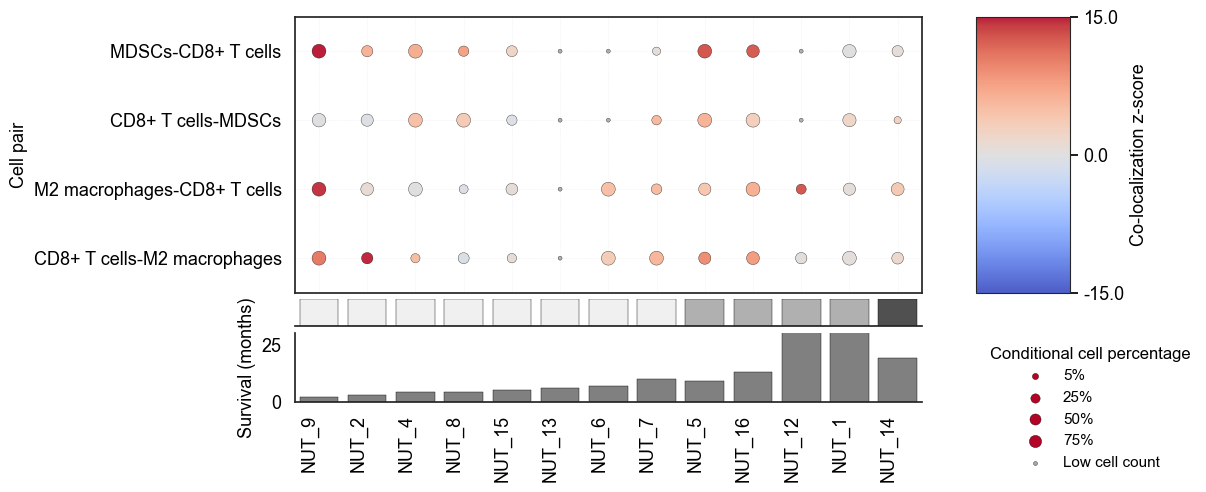

In [490]:
celltype_order = [
    "MDSCs",
    "Granulocytes",
    "M2 macrophages",
    "M1/M2 macrophages",
    "M1 macrophages",
    "DCs",
    "Mast cells",
    "Treg T cells",
    "NK cells",
    "B cells",
    "PCs",
    "CD4+ T cells",
]

a = cozi_dotplot(mdscs_cd8, 
             column_name="cell_pair", 
             figsize=(10,5), 
             max_dot_size=100, 
             zscore_col="zscore",
             survival_data=survival_data,
             survival_col="survival_time_months",
            patient_col="patient_ID",
            survival_ylim=(0,30),
            save_path="/Users/jawadalaaedeen/Desktop/images_for_figures/figure_4/MDSC_CD8_interaction_dotplot.pdf",
            show_legend=True,
            vmin=-15,
            vcenter=0,
            vmax=15
             )

In [587]:
def cozi_dotplot_facet_by_site(
    res,
    column_name="celltype_A",
    zscore_col="zscore",
    patient_col="patient_exp",
    celltype_order=None,
    figsize=None,
    save_path=None,
    size_scale=3,
    max_dot_size=250,
    min_dot_size=8,
    vmin=None,
    vcenter=0,
    vmax=None,
    survival_data=None,
    survival_col="survival",
    tumor_site_col="tumor_site",
    tumor_site_colors=None,
    survival_ylim=None,
    show_legend=True,
    site_width_ratios=None, 
):

    df = res.copy()

    df = df[[patient_col, column_name, zscore_col, "cond_percent"]].copy()

    df[patient_col] = df[patient_col].astype(str)
    df[column_name] = df[column_name].astype(str)
    df[zscore_col] = pd.to_numeric(df[zscore_col], errors="coerce")
    df["cond_percent"] = pd.to_numeric(df["cond_percent"], errors="coerce")

    # cell types
    if celltype_order is not None:
        celltypes = [ct for ct in celltype_order if ct in df[column_name].unique()]
    else:
        celltypes = df[column_name].drop_duplicates().tolist()

    # survival data
    if survival_data is not None:
        surv_df = survival_data[[patient_col, survival_col, tumor_site_col]].copy()
        surv_df[patient_col] = surv_df[patient_col].astype(str)
    else:
        raise ValueError("survival_data with tumor_site is required for faceting")

    # group patients by tumor site, sorted by survival time (ascending)
    def sorted_patients(group):
        merged = group.merge(
            surv_df[[patient_col, survival_col]].drop_duplicates(),
            on=patient_col,
            how="left"
        )
        return merged.sort_values(survival_col)[patient_col].tolist()

    site_to_patients = (
        surv_df.groupby(tumor_site_col)
        .apply(lambda g: g.sort_values(survival_col)[patient_col].tolist())
        .to_dict()
    )

    unique_sites = list(site_to_patients.keys())
    n_sites = len(unique_sites)

    # validate / build site_width_ratios
    if site_width_ratios is not None:
        if len(site_width_ratios) != n_sites:
            raise ValueError(
                f"site_width_ratios has {len(site_width_ratios)} values "
                f"but there are {n_sites} tumor sites: {unique_sites}"
            )
        panel_widths = list(site_width_ratios)
    else:
        # Default: proportional to number of patients in each site
        panel_widths = [len(site_to_patients[s]) for s in unique_sites]

    # ---- full grid ----
    patients_all = [p for s in unique_sites for p in site_to_patients[s]]

    full_index = pd.MultiIndex.from_product(
        [patients_all, celltypes],
        names=[patient_col, column_name]
    )

    df = (
        df.set_index([patient_col, column_name])
        .reindex(full_index)
        .reset_index()
    )

    celltype_to_y = {ct: i for i, ct in enumerate(celltypes)}
    df["y"] = df[column_name].map(celltype_to_y)

    # ---- NA handling ----
    df["is_na"] = df[zscore_col].isna()
    df["cond_percent_plot"] = df["cond_percent"].fillna(0)

    df["dot_size"] = np.sqrt(df["cond_percent_plot"].clip(lower=0)) * size_scale * 10
    df["dot_size"] = df["dot_size"].clip(lower=min_dot_size, upper=max_dot_size)
    df.loc[df["is_na"], "dot_size"] = min_dot_size

    # ---- color scaling ----
    valid_z = df.loc[~df["is_na"], zscore_col]
    if vmin is None or vmax is None:
        max_abs = np.nanmax(np.abs(valid_z)) if len(valid_z) > 0 else 1
        if not np.isfinite(max_abs) or max_abs == 0:
            max_abs = 1
        vmin, vmax = -max_abs, max_abs

    norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    # ---- figure ----
    if figsize is None:
        figsize = (4 * n_sites + 3, len(celltypes) * 0.5 + 3)

    fig = plt.figure(figsize=figsize)

    gs = GridSpec(
        nrows=3,
        ncols=n_sites + 1,
        width_ratios=panel_widths + [0.15],   # <-- custom ratios here
        height_ratios=[4, 0.4, 1],
        wspace=0.15,
        hspace=0.05
    )

    cax = fig.add_subplot(gs[0, -1])
    lax = fig.add_subplot(gs[2, -1])
    lax.axis("off")

    # ---- loop over tumor sites ----
    for i, site in enumerate(unique_sites):

        site_patients = site_to_patients[site]   # already sorted by survival

        ax  = fig.add_subplot(gs[0, i])
        tax = fig.add_subplot(gs[1, i], sharex=ax)
        sax = fig.add_subplot(gs[2, i], sharex=ax)

        sub_df = df[df[patient_col].isin(site_patients)].copy()

        # local x mapping (order matches sorted site_patients)
        local_x = {p: j for j, p in enumerate(site_patients)}
        sub_df["x"] = sub_df[patient_col].map(local_x)

        # ---- dotplot ----
        sc = ax.scatter(
            sub_df.loc[~sub_df["is_na"], "x"],
            sub_df.loc[~sub_df["is_na"], "y"],
            c=sub_df.loc[~sub_df["is_na"], zscore_col],
            s=sub_df.loc[~sub_df["is_na"], "dot_size"],
            cmap="coolwarm",
            norm=norm,
            edgecolor="black",
            linewidth=0.25,
        )

        ax.scatter(
            sub_df.loc[sub_df["is_na"], "x"],
            sub_df.loc[sub_df["is_na"], "y"],
            s=sub_df.loc[sub_df["is_na"], "dot_size"],
            color="darkgrey",
            edgecolor="black",
            linewidth=0.25,
        )

        ax.set_title(site, fontsize=13)

        if i == 0:
            ax.set_yticks(range(len(celltypes)))
            ax.set_yticklabels(celltypes, fontsize=13)
            ax.set_ylabel("Cell pair", fontsize=13)
        else:
            ax.set_yticks([])

        ax.set_xticks([])
        ax.invert_yaxis()
        ax.grid(True, linestyle=":", linewidth=0.4, alpha=0.5)

        # ---- tumor strip ----
        for j in range(len(site_patients)):
            color = tumor_site_colors.get(site, "white") if tumor_site_colors else "grey"
            tax.bar(j, 1, color=color, edgecolor="black", linewidth=0.3)

        tax.set_xlim(-0.5, len(site_patients) - 0.5)
        tax.set_ylim(0, 1)
        tax.spines["bottom"].set_visible(True)
        tax.spines["bottom"].set_linewidth(0.8)
        tax.spines["top"].set_visible(False)
        tax.spines["right"].set_visible(False)
        tax.spines["left"].set_visible(False)
        tax.set_yticks([])
        tax.set_xticks([])

        # ---- survival ----
        surv_sub = surv_df[surv_df[patient_col].isin(site_patients)]
        survival_values = (
            surv_sub.set_index(patient_col)
            .reindex(site_patients)[survival_col]   # respects sorted order
        )

        sax.bar(
            range(len(site_patients)),
            survival_values,
            color="grey",
            edgecolor="black",
            linewidth=0.3,
        )

        sax.set_xticks(range(len(site_patients)))
        sax.set_xticklabels(site_patients, rotation=90, fontsize=13)

        if i == 0:
            sax.set_ylabel("Survival (months)", fontsize=11)
        else:
            sax.set_yticks([])
            sax.spines["left"].set_visible(False)

        if survival_ylim is not None:
            sax.set_ylim(survival_ylim)

        sax.spines["top"].set_visible(False)
        sax.spines["right"].set_visible(False)

    #colorbar
    cbar = fig.colorbar(sc, cax=cax)
    cbar.set_label("Neighbor Preference Z-score")
    cbar.set_ticks([vmin, vcenter, vmax])

    if show_legend:
        legend_vals = [5, 25, 50, 75]
    
        handles = []
        for val in legend_vals:
            size = np.sqrt(val) * size_scale * 3
            size = np.clip(size, min_dot_size, max_dot_size)
            handles.append(
                lax.scatter([], [], s=size, color="#B30326", edgecolor="black", linewidth=0.25)
            )
    
        na_handle = lax.scatter([], [], s=min_dot_size, color="darkgrey", edgecolor="black")
    
        legend1 = lax.legend(
            handles + [na_handle],
            [f"{v}%" for v in legend_vals] + ["Low cell count"],
            title="Conditional cell percentage",
            frameon=False,
            loc="upper left",
            fontsize=12,
            title_fontsize=13
        )
    
        lax.add_artist(legend1)  # keep this legend when adding another
    
        # tumor_site legend
        if tumor_site_colors is not None:
    
            site_handles = [
                Patch(facecolor=color, edgecolor="black", label=site)
                for site, color in tumor_site_colors.items()
            ]
    
            lax.legend(
                handles=site_handles,
                title="Tumor site",
                frameon=False,
                loc="lower right",
                fontsize=12,
                title_fontsize=13
            )
    
    # save
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_66977/3533807919.py:62: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_66977/3533807919.py:63: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



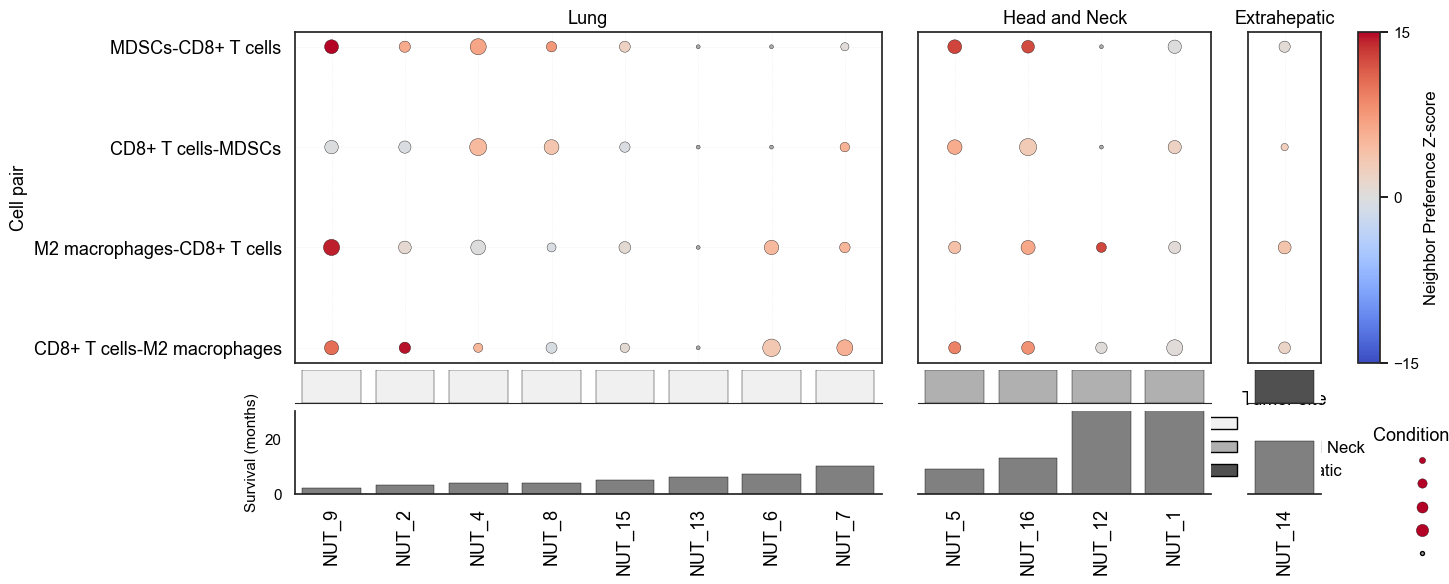

In [588]:
cozi_dotplot_facet_by_site(
    mdscs_cd8,
    column_name="cell_pair",
    zscore_col="zscore",
    patient_col="patient_ID",
    survival_data=survival_data,
    survival_col="survival_time_months",
    tumor_site_col="tumor_site",
    tumor_site_colors=tumor_site_colors,
    survival_ylim=(0, 30),
    vmin=-15,
    vmax=15,
    figsize=(14, 6),
    site_width_ratios=[4,2,0.5],
    show_legend=True,
    save_path="/Users/jawadalaaedeen/Desktop/images_for_figures/figure_4/MDSC_M2_CD8_interaction_dotplot_by_site.pdf",)